# Gradient Boosting (LightGBM)

**Requisitos:** Machine Learning / Deep Learning (2do Corte)
**Universidad del Norte**

````{admonition} Objetivos de aprendizaje
:class: tip

1. **Formalizar matemáticamente** un problema de regresión espacio-temporal sobre un grafo $G=(V,E)$: tensores $X \in \mathbb{R}^{N\times T \times F}$ y función objetivo $f_\theta$.
2. **Derivar desde primeros principios** el algoritmo de Gradient Boosting {cite}`friedman2001greedy` como descenso de gradiente funcional, demostrando por qué el residuo es el gradiente negativo bajo pérdida cuadrática.
3. **Explicar y demostrar** las innovaciones de LightGBM {cite}`ke2017lightgbm`: *histogram-based splitting*, *leaf-wise growth* y **GOSS**, incluyendo la cota de error de GOSS.
4. **Construir** *features* espacio-temporales (lags, rolling stats, **lag espacial** vía $A_{\text{norm}}X$) y justificar por qué evitan *leakage*.
5. **Diseñar validación** que respete la dependencia temporal (*walk-forward*) y demostrar por qué el $k$-fold aleatorio es inválido con autocorrelación {cite}`roberts2017crossvalidation`.
6. **Evaluar e interpretar** con MAE/RMSE/MAPE, importancia por ganancia y SHAP {cite}`lundberg2017unified`.
7. **Comparar** contra *baselines* (persistencia, ARIMA) y ubicar la familia GBM+FE en el panorama de *benchmarks* (M5, {cite}`makridakis2022m5`) frente a STGNN/TFT.
````

````{admonition} Mapa del cuaderno
:class: note

| # | Sección | Contenido clave |
|:-:|---|---|
| 1 | Fundamentos matemáticos | Grafo $G$, Laplaciano, índice de Moran I, demostraciones |
| 2 | Dataset SZ-Taxi | Carga, EDA extendido, construcción de la matriz de adyacencia |
| 3 | Gradient Boosting | Derivación matemática completa {cite}`friedman2001greedy` |
| 4 | LightGBM | Histogramas, *leaf-wise growth* y GOSS, con demostraciones |
| 5 | Feature engineering | Lags, rolling stats y lag espacial, verificación anti-*leakage* |
| 6 | ⏳ Validación temporal | *Walk-forward* vs. K-Fold aleatorio (demostración de sesgo) |
| 7 | Entrenamiento e interpretabilidad | *Tuning*, curva de aprendizaje, SHAP |
| 8 | Baselines y discusión crítica | Persistencia, ARIMA, condiciones de ventaja de GBM+FE |
| 9 | [Extensión] STGNN | Implementación de T-GCN como contraste |
| 10 | Referencias | Bibliografía indexada en Web of Science |

````


## Fundamentos matemáticos de la regresión espacio-temporal

### Definición formal del problema

Sea un **grafo espacial** $G=(V,E)$ con $|V|=N$ unidades (paraderos, segmentos viales). Definimos:

- **Matriz de adyacencia** $A \in \mathbb{R}^{N\times N}_{\ge 0}$, donde $A_{ij}>0$ si $i$ y $j$ están conectados (y su magnitud puede codificar distancia, tiempo de viaje o un peso binario).
- **Matriz de grados** $D = \text{diag}(d_1,\dots,d_N)$, con $D_{ii} = d_i = \sum_j A_{ij}$.
- **Laplaciano del grafo** (fundamental en GCN y en la teoría espectral de grafos):

$$L = D - A, \qquad L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}$$

- El Laplaciano normalizado $L_{\text{sym}}$ es simétrico semidefinido positivo, con autovalores $\lambda \in [0,2]$; sus autovectores forman la base de Fourier del grafo {cite}`shuman2013emerging`; fundamento matemático que después usan las **Graph Neural Networks** para generalizar la convolución al dominio no-euclídeano.

### Obtención de $L_{\text{sym}}$

- Partimos del **Laplaciano combinatorio** $L = D - A$, donde $D = \text{diag}(d_1,\dots,d_N)$ es la matriz diagonal de grados con $D_{ii} = d_i$, y $A$ es la matriz de adyacencia. La normalización simétrica se define multiplicando por $D^{-1/2}$ a izquierda y derecha:

$$
L_{\text{sym}} = D^{-1/2} L D^{-1/2} = D^{-1/2}(D - A)D^{-1/2}
$$

- **Paso 1: distribuir el producto sobre la resta.** Como el producto matricial se distribuye sobre la suma (y la resta), obtenemos dos términos separados:

$$
L_{\text{sym}} = D^{-1/2} D D^{-1/2} \; - \; D^{-1/2} A D^{-1/2}
$$

  - Este paso es válido porque la multiplicación de matrices es asociativa y distributiva respecto a la suma: $M(X - Y) = MX - MY$ para cualquier matriz $M$ compatible.

- **Paso 2: simplificar el primer término.** Como $D$ es diagonal con entradas positivas $D_{ii} = d_i$, su raíz cuadrada $D^{1/2}$ también es diagonal, con entradas $D^{1/2}_{ii} = \sqrt{d_i}$, y su inversa $D^{-1/2}$ tiene entradas $D^{-1/2}_{ii} = 1/\sqrt{d_i}$.

  - Reescribimos $D$ como producto de sus raíces: $D = D^{1/2} D^{1/2}$.
  - Sustituyendo:
  
  $$
  D^{-1/2} D D^{-1/2} = D^{-1/2} \left(D^{1/2} D^{1/2}\right) D^{-1/2} = \left(D^{-1/2} D^{1/2}\right)\left(D^{1/2} D^{-1/2}\right)
  $$
  
  - Como todas son matrices diagonales, el producto se hace entrada a entrada y conmuta libremente:
  
  $$
  D^{-1/2}_{ii} D^{1/2}_{ii} = \frac{1}{\sqrt{d_i}} \cdot \sqrt{d_i} = 1 \quad \text{para cada } i
  $$
  
  - Por lo tanto $D^{-1/2} D^{1/2} = I$, y en consecuencia:
  
  $$
  D^{-1/2} D D^{-1/2} = I \cdot I = I
  $$

- **Paso 3: el segundo término no se simplifica.** El mismo truco no aplica a $D^{-1/2} A D^{-1/2}$ porque $A$ no es diagonal: sus entradas fuera de la diagonal ($A_{ij}$ con $i \neq j$) codifican las aristas del grafo. Al multiplicar:

  $$
  \left(D^{-1/2} A D^{-1/2}\right)_{ij} = \frac{A_{ij}}{\sqrt{d_i}\sqrt{d_j}}
  $$

  - Cada entrada queda **reescalada por el producto de las raíces de los grados de los dos nodos que conecta**, pero la estructura no diagonal de $A$ se preserva; no hay cancelación posible como en el paso anterior.

- **Paso 4: ensamblar el resultado.** Sustituyendo ambos términos de vuelta:

$$
L_{\text{sym}} = I - D^{-1/2} A D^{-1/2}
$$

- **Motivación de por qué normalizar así.** Sin este reescalamiento, los autovalores del Laplaciano combinatorio $L$ dependen directamente de la magnitud de los grados: **un nodo con grado muy alto (hub, $d_i$ grande) infla la escala de $L$ mucho más que un nodo periférico**. Esto genera dos problemas concretos:

  - Los autovalores de $L$ no están acotados a un rango fijo; crecen con el grado máximo del grafo ($\lambda_{\max}(L) \leq 2 d_{\max}$, con $d_{\max} = \max_i d_i$), lo que hace que el espectro cambie drásticamente entre grafos de distinta densidad.
  - En el entrenamiento de una GNN, esto provoca gradientes de escala muy distinta según la región del grafo, especialmente si coexisten nodos de $d_i$ alto y $d_i$ bajo, lo que desestabiliza la optimización.

  - Al normalizar con $D^{-1/2}$ a ambos lados, cada entrada $A_{ij}$ pasa de ser un peso absoluto a un peso relativo respecto a la conectividad conjunta $d_i, d_j$ de ambos nodos, y el espectro completo de $L_{\text{sym}}$ queda acotado en $[0, 2]$ independientemente del tamaño o la distribución de grados del grafo.

  - Esta cota espectral fija es justamente lo que permite construir filtros polinomiales estables (como en ChebNet o GCN): reescalando
  
  $$\tilde{L} = \frac{2}{\lambda_{\max}} L_{\text{sym}} - I$$
  
  para llevar el espectro a $[-1,1]$, se pueden aplicar polinomios de Chebyshev sin riesgo de explosión numérica al apilar capas.

- **Señal espacio-temporal**: tensor $X \in \mathbb{R}^{N\times T\times F}$, donde $X_{i,t,\cdot}$ es el vector de $F$ variables explicativas del nodo $i$ en el instante $t$.
- **Variable objetivo**: $Y \in \mathbb{R}^{N\times T}$ (univariante) o $\mathbb{R}^{N\times T\times K}$ (multivariante).

El problema de **forecasting espacio-temporal** consiste en aprender una función $f_\theta$ tal que:

$$\hat{Y}_{\,\cdot\,,\,t+1:t+H} \;=\; f_\theta\big(X_{\cdot,\,t-L+1:t},\; A\big)$$

es decir, predecir un **horizonte** $H$ de pasos futuros usando una **ventana de lookback** $L$ y la estructura de grafo $A$. En este cuaderno trabajamos el caso $H=1$ (un paso adelante), el más común como punto de partida.

### Autocorrelación espacial: ¿por qué el espacio importa estadísticamente?

Antes de justificar cualquier modelo, conviene **cuantificar** si existe dependencia espacial en los datos, usando el **índice de Moran I** {cite}`moran1950notes`, el estadístico estándar de autocorrelación espacial global:

$$
I = \frac{N}{\sum_{i}\sum_{j} A_{ij}} \cdot \frac{\sum_{i}\sum_{j} A_{ij}(x_i-\bar{x})(x_j-\bar{x})}{\sum_i (x_i - \bar x)^2}
$$

- $I \approx 1$: fuerte autocorrelación espacial positiva (nodos vecinos tienen valores similares).
- $I \approx 0$: ausencia de estructura espacial (equivalente a ruido espacial aleatorio).
- $I \approx -1$: autocorrelación negativa (patrón de "tablero de ajedrez").


El índice de Moran es una **correlación de Pearson entre $x_i$ y el valor de sus vecinos**, no entre dos variables distintas.

- El numerador pondera por $A_{ij}$ el producto de desviaciones $(x_i-\bar x)(x_j-\bar x)$ de cada par conectado; el denominador es la varianza muestral de $x$, igual que en una correlación clásica.
- El factor $N/\sum_i\sum_j A_{ij}$ corrige que cada nodo aparece varias veces en el numerador (una por vecino) pero solo una vez en el denominador, manteniendo $I$ aproximadamente acotado en $[-1,1]$.
- Por eso $I\approx 1$, $I\approx 0$ e $I\approx -1$ se leen igual que una correlación: relación positiva, nula o negativa entre un nodo y sus vecinos.
- El grado $d_i = \sum_j A_{ij}$ suma solo sobre los $j$ con $A_{ij} \neq 0$, es decir, cuenta las aristas reales del nodo $i$ en $G$ (su número de vecinos más cercanos), no el total de nodos $N$: si $N=500$ paraderos pero cada uno se conecta solo con sus 4 o 5 vecinos más cercanos, $d_i \approx 4$ o $5$, muy lejos de $500$.

Bajo la hipótesis nula de aleatoriedad espacial completa, $\mathbb{E}[I] = -1/(N-1)$, y existe una fórmula cerrada para $\text{Var}(I)$ que permite construir un $z$-score y un valor $p$ {cite}`cliff1981spatial`. **Si $I$ es significativamente mayor que $\mathbb{E}[I]$, queda estadísticamente justificado explotar la estructura del grafo como información predictiva**: es precisamente lo que hace el *lag espacial* que construiremos en la Sección 5.

### ¿Por qué no basta con series de tiempo "clásicas" por nodo?

Un modelo ARIMA o un Exponential Smoothing ajustado **independientemente** para cada nodo $i$:

- Ignora la dependencia espacial: un choque de demanda en un nodo vecino no informa la predicción de $i$.
- No comparte estadística entre nodos con poca historia (sensores nuevos, rutas nuevas), problema de *cold start*.
- Es costoso de mantener en producción: un modelo distinto por cada uno de los $N$ nodos, sin compartir parámetros.

Por ello, dos familias dominan la literatura y la práctica:

| Familia | Cómo captura el espacio | Cómo captura el tiempo | Referencia clave |
|---|---|---|---|
| **GBM + feature engineering** (esta sección) | Features derivadas de vecinos ($A_{\text{norm}}X$), agregaciones por zona | Lags, rolling stats, variables de calendario | {cite}`ke2017lightgbm`; {cite}`friedman2001greedy` |
| **STGNN** (Spatio-Temporal GNN) | Convoluciones de grafo aprendidas (GCN/GAT) sobre $A$ | Recurrencia (GRU/LSTM) o atención temporal | {cite}`zhao2020tgcn` (T-GCN); {cite}`yu2018stgcn` (STGCN) |

Esta sección se enfoca en la primera familia porque **domina en velocidad de entrenamiento, interpretabilidad y facilidad de productivización** (MLOps), y porque, como demostraremos empíricamente en la Sección 7, **alcanza un desempeño competitivo**, consistente con los hallazgos del *M5 Forecasting Competition* {cite}`makridakis2022m5`, donde los métodos basados en gradient boosting (LightGBM) dominaron el *leaderboard* de series de tiempo tabulares a gran escala.

### Objetivos para target de conteo en LightGBM

- **`"poisson"`**: asume $\text{Var}(y) \approx \mathbb{E}[y]$; optimiza log-verosimilitud de Poisson con link logarítmico (garantiza predicciones no negativas). Usar `poisson_max_delta_step` para estabilizar el gradiente cuando hay muchos ceros. Apropiado cuando la dispersión de $y$ es moderada y no hay sobre-dispersión fuerte.

```python
params_poisson = {
    "objective": "poisson",
    "metric": "poisson",            # o "rmse"/"mae" para reportar en escala interpretable
    "poisson_max_delta_step": 0.7,  # estabiliza el gradiente cuando y tiene muchos ceros
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "verbose": -1
}
```

- **`"tweedie"`**: interpola entre Poisson ($p=1$) y Gamma ($p=2$) vía `tweedie_variance_power` ($1<p<2$, ajustado por CV); maneja **sobre-dispersión** (varianza $\gg$ media) y **masa en cero + cola continua positiva**, patrón típico en demanda agregada. Preferible cuando Poisson subestima la varianza real de los conteos.

```python
params_tweedie = {
    "objective": "tweedie",
    "tweedie_variance_power": 1.3,  # típicamente entre 1.1 y 1.9; se ajusta por CV
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "verbose": -1
}
```

- **Selección entre ambos:** tratar como hiperparámetro y elegir por validación *walk-forward*, comparando *deviance*/log-verosimilitud (no solo MAE/RMSE).

### Métricas adecuadas para targets de conteo

- **MAE y RMSE**: reportables por estar en la unidad original (interpretables), pero no respetan la heterocedasticidad propia de los conteos (varianza que crece con la media); usar solo como complemento descriptivo, no como métrica principal de selección.

- **Poisson deviance**: la métrica más alineada con `objective="poisson"`, porque penaliza cada error relativo a la varianza esperada en ese nivel de $y$, en vez de en escala absoluta como MSE. Es la métrica estándar en la literatura de modelos de conteo para comparar modelos entrenados con verosimilitud Poisson/Tweedie.

$$
D_{\text{Poisson}} = 2\sum_i \left[ y_i \log\left(\frac{y_i}{\hat y_i}\right) - (y_i - \hat y_i) \right]
$$

- **Tweedie deviance**: análoga a la anterior pero generalizada al parámetro $p$ de Tweedie; se usa cuando el modelo fue entrenado con `objective="tweedie"`, para mantener coherencia entre la función de pérdida de entrenamiento y la métrica de evaluación.

- **RMSLE** (*Root Mean Squared Log Error*): comprime el efecto de valores altos atípicos, útil cuando la distribución de $y$ tiene cola derecha pesada (picos de demanda). Penaliza más los errores relativos en conteos bajos que en conteos altos, lo opuesto a RMSE.

$$
\text{RMSLE} = \sqrt{\frac{1}{n}\sum_i \left(\log(1+y_i) - \log(1+\hat y_i)\right)^2}
$$

- **Regla práctica de reporte**: usar la *deviance* correspondiente al `objective` de entrenamiento como métrica principal de selección/comparación de modelos (coherencia pérdida-métrica), y acompañarla de MAE/RMSE/RMSLE como métricas secundarias interpretables para el lector no especializado en modelos de conteo.

```python
import numpy as np

def poisson_deviance(y_true, y_pred, eps=1e-8):
    # y_true: conteos observados (enteros no negativos)
    # y_pred: conteos predichos por el modelo (deben ser > 0 por el link log de Poisson)
    # eps evita log(0) cuando y_true=0, caso muy común en datos de conteo
    y_pred = np.clip(y_pred, eps, None)  # asegura que no haya predicciones <= 0
    term = np.where(y_true == 0, 0, y_true * np.log(y_true / y_pred))  # término y*log(y/y_hat), definido como 0 si y=0
    return 2 * np.mean(term - (y_true - y_pred))  # deviance promedio sobre las n observaciones

def rmsle(y_true, y_pred):
    # y_true: conteos observados
    # y_pred: conteos predichos (se recortan a >= 0 porque log requiere argumento no negativo)
    y_pred = np.clip(y_pred, 0, None)  # el modelo no debe predecir conteos negativos
    log_diff = np.log1p(y_true) - np.log1p(y_pred)  # log1p(x) = log(1+x), evita log(0)
    return np.sqrt(np.mean(log_diff ** 2))  # raíz del error cuadrático medio en escala log
```

### Demostraciones: Fundamentos matemáticos de la regresión espacio-temporal

````{dropdown} Mostrar el desarrollo matemático completo (clic para expandir)
:color: info

#### Demostración 1: $L$ y $L_{\text{sym}}$ son semidefinidas positivas

**Proposición.** Para todo $x \in \mathbb{R}^N$, $x^\top L x \ge 0$, donde $L = D - A$.

**Demostración.** Partimos de la forma cuadrática:

$$x^\top L x = x^\top D x - x^\top A x = \sum_i d_i x_i^2 - \sum_{i,j} A_{ij} x_i x_j$$

Usando $d_i = \sum_j A_{ij}$, reescribimos el primer término como:

$$\sum_i d_i x_i^2 = \sum_i \left(\sum_j A_{ij}\right) x_i^2 = \sum_{i,j} A_{ij} x_i^2$$

Por simetría de $A$ ($A_{ij} = A_{ji}$), también se cumple $\sum_{i,j} A_{ij} x_i^2 = \sum_{i,j} A_{ij} x_j^2$, de modo que podemos escribir:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij} x_i^2 + \frac{1}{2}\sum_{i,j} A_{ij} x_j^2 - \sum_{i,j} A_{ij} x_i x_j = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2$$

Como $A_{ij} \ge 0$ por definición y $(x_i - x_j)^2 \ge 0$ para todo par $(i,j)$, cada término de la suma es no negativo, por lo tanto:

$$x^\top L x = \frac{1}{2}\sum_{i,j} A_{ij}(x_i - x_j)^2 \ge 0 \qquad \forall x \in \mathbb{R}^N$$

Esto prueba que $L$ es semidefinida positiva. El mismo argumento aplicado a $L_{\text{sym}} = I - D^{-1/2}AD^{-1/2}$, sustituyendo $x_i \to x_i/\sqrt{d_i}$, da:

$$x^\top L_{\text{sym}} x = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{x_i}{\sqrt{d_i}} - \frac{x_j}{\sqrt{d_j}}\right)^2 \ge 0$$

lo que establece que $L_{\text{sym}}$ también es semidefinida positiva. $\blacksquare$

#### Demostración 2: los autovalores de $L_{\text{sym}}$ están acotados en $[0,2]$

**Proposición.** Todo autovalor $\lambda$ de $L_{\text{sym}}$ satisface $0 \le \lambda \le 2$.

**Demostración.** La cota inferior $\lambda \ge 0$ se sigue directamente de la Demostración 1: al ser $L_{\text{sym}}$ semidefinida positiva, su forma cuadrática es no negativa para todo $x$, y en particular para los autovectores.

Para la cota superior, sea $v$ autovector unitario de $L_{\text{sym}}$ asociado a $\lambda$, de modo que $\lambda = v^\top L_{\text{sym}} v$. Usando la expresión obtenida en la Demostración 1:

$$\lambda = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{v_i}{\sqrt{d_i}} - \frac{v_j}{\sqrt{d_j}}\right)^2$$

Aplicamos la desigualdad $(a-b)^2 \le 2a^2 + 2b^2$ a cada término:

$$\lambda \le \sum_{i,j} A_{ij}\left(\frac{v_i^2}{d_i} + \frac{v_j^2}{d_j}\right) = \sum_i \frac{v_i^2}{d_i}\sum_j A_{ij} + \sum_j \frac{v_j^2}{d_j}\sum_i A_{ij} = \sum_i \frac{v_i^2}{d_i}\cdot d_i + \sum_j \frac{v_j^2}{d_j}\cdot d_j = 2\sum_i v_i^2 = 2$$

donde la última igualdad usa que $v$ es unitario. Por lo tanto $\lambda \le 2$, con igualdad alcanzada cuando el grafo (o una componente conexa) es bipartito, caso en el cual existe una partición $V = V_1 \cup V_2$ tal que tomando $v_i = \sqrt{d_i}$ para $i \in V_1$ y $v_i = -\sqrt{d_i}$ para $i \in V_2$ (normalizado), se satura la desigualdad de Cauchy-Schwarz en cada término. $\blacksquare$

#### Demostración 3: la base de Fourier del grafo separa componentes suaves de componentes oscilantes

**Proposición.** Sea $L_{\text{sym}} = U\Lambda U^\top$ la descomposición espectral, con $\Lambda = \text{diag}(\lambda_1 \le \cdots \le \lambda_N)$ y columnas de $U$ los autovectores $u_1,\dots,u_N$. Definiendo la transformada de Fourier del grafo $\hat{x} = U^\top x$, el autovalor $\lambda_k$ mide la variación total de $u_k$ sobre las aristas del grafo.

**Demostración.** Por definición de autovector, $L_{\text{sym}} u_k = \lambda_k u_k$, y por lo tanto:

$$\lambda_k = u_k^\top L_{\text{sym}} u_k = \frac{1}{2}\sum_{i,j} A_{ij}\left(\frac{(u_k)_i}{\sqrt{d_i}} - \frac{(u_k)_j}{\sqrt{d_j}}\right)^2$$

Esta cantidad es exactamente la **variación de Dirichlet** de $u_k$ sobre el grafo: mide cuánto difiere $u_k$ entre nodos vecinos, ponderado por la fuerza de la conexión $A_{ij}$. Si $\lambda_k$ es pequeño, $u_k$ toma valores casi idénticos en nodos conectados (componente suave); si $\lambda_k$ es grande (cercano a la cota 2 de la Demostración 2), $u_k$ alterna signo u magnitud entre vecinos (componente oscilante).

Dado que $X = U\hat{X}$ (la inversa de la transformada), cualquier señal sobre el grafo se descompone como combinación lineal $X = \sum_k \hat{x}_k u_k$, y su "contenido de alta frecuencia" queda determinado por el peso de los coeficientes $\hat{x}_k$ asociados a $\lambda_k$ grandes. En particular, el operador $A_{\text{norm}} = D^{-1/2}AD^{-1/2} = I - L_{\text{sym}}$ tiene autovalores $1-\lambda_k \in [-1,1]$, de modo que al aplicar $A_{\text{norm}}$ a $X$, los componentes de baja frecuencia ($\lambda_k$ pequeño, $1-\lambda_k$ cercano a 1) se preservan casi intactos, mientras que los de alta frecuencia se atenúan o invierten signo. Esto demuestra formalmente que $A_{\text{norm}}X$, el lag espacial que se construye en la Sección 5, opera como un **filtro pasa-bajas** sobre la señal espacial. $\blacksquare$

#### Demostración 4: valor esperado del índice de Moran bajo aleatoriedad espacial completa

**Proposición.** Bajo la hipótesis nula $H_0$ de aleatoriedad espacial completa (cualquier permutación de los valores $x_1,\dots,x_N$ entre los $N$ nodos es igualmente probable), $\mathbb{E}[I] = -\dfrac{1}{N-1}$.

**Demostración.** Sea $S_0 = \sum_{i,j} A_{ij}$ y $z_i = x_i - \bar{x}$, de modo que:

$$I = \frac{N}{S_0}\cdot\frac{\sum_{i,j}A_{ij}z_iz_j}{\sum_i z_i^2}$$

Bajo $H_0$, la aleatorización asigna los valores observados $\{x_1,\dots,x_N\}$ a las $N$ ubicaciones mediante una permutación uniforme, de manera que el denominador $\sum_i z_i^2$ es una constante (no depende de la permutación), y basta calcular la esperanza del numerador sobre las permutaciones. Para $i \ne j$, por simetría de la permutación uniforme, cada par ordenado $(z_i, z_j)$ tiene la misma distribución conjunta que cualquier otro par distinto tomado sin reemplazo de $\{z_1,\dots,z_N\}$. Un resultado estándar de muestreo sin reemplazo establece que:

$$\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N} \qquad \text{para } i\ne j$$

(esto se deriva de que $\sum_i z_i = 0$, así que $0 = \left(\sum_i z_i\right)^2 = \sum_i z_i^2 + \sum_{i\ne j} z_iz_j$, y por simetría todos los $N(N-1)$ términos $z_iz_j$ con $i\ne j$ tienen la misma esperanza, de donde se despeja la expresión anterior).

Sustituyendo:

$$\mathbb{E}\left[\sum_{i,j}A_{ij}z_iz_j\right] = \sum_{i\ne j}A_{ij}\,\mathbb{E}[z_iz_j] = -\frac{1}{N-1}\cdot\frac{\sum_k z_k^2}{N}\sum_{i\ne j}A_{ij} = -\frac{S_0}{N(N-1)}\sum_k z_k^2$$

(usando que $A_{ii}=0$ y por lo tanto $\sum_{i\ne j}A_{ij}=S_0$). Finalmente:

$$\mathbb{E}[I] = \frac{N}{S_0}\cdot\frac{1}{\sum_k z_k^2}\cdot\left(-\frac{S_0}{N(N-1)}\sum_k z_k^2\right) = -\frac{1}{N-1} \qquad \blacksquare$$


#### Demostración 5: la convolución de grafo de primer orden se reduce al lag espacial

**Proposición.** La capa de convolución de grafo de {cite}`kipf2017semisupervised`, obtenida por truncamiento a primer orden ($K=1$) de la aproximación de Chebyshev del filtro espectral $g_\theta(L_{\text{sym}})$, es algebraicamente equivalente a aplicar el operador de lag espacial $\tilde{A}_{\text{norm}}$ a la señal $X$, seguido de una transformación lineal $W$.

**Demostración.** Un filtro espectral general actúa sobre una señal $x$ como $g_\theta(L_{\text{sym}})x = U g_\theta(\Lambda) U^\top x$, cuyo costo computacional $O(N^2)$ (por la diagonalización de $U$) motiva aproximar $g_\theta(\Lambda)$ mediante un polinomio de Chebyshev truncado en orden $K$:

$$g_\theta(L_{\text{sym}}) \approx \sum_{k=0}^{K}\theta_k T_k(\tilde{L}_{\text{sym}})$$

donde $\tilde{L}_{\text{sym}} = \dfrac{2}{\lambda_{\max}}L_{\text{sym}} - I$ reescala el espectro a $[-1,1]$ para que los polinomios de Chebyshev $T_k$ estén bien definidos, y $T_0(y)=1$, $T_1(y)=y$, $T_k(y)=2yT_{k-1}(y)-T_{k-2}(y)$.

Truncando en $K=1$ y fijando $\lambda_{\max}\approx 2$ (justificado por la Demostración 2), se obtiene $\tilde{L}_{\text{sym}} \approx L_{\text{sym}} - I$, y el filtro se reduce a:

$$g_\theta(L_{\text{sym}})x \approx \theta_0 x + \theta_1(L_{\text{sym}}-I)x = \theta_0 x + \theta_1(-D^{-1/2}AD^{-1/2})x$$

usando que $L_{\text{sym}} - I = -D^{-1/2}AD^{-1/2}$. Restringiendo el número de parámetros libres mediante $\theta_0 = -\theta_1 = \theta$ (la elección estándar de {cite}`kipf2017semisupervised` para evitar sobreajuste y controlar el número de operaciones por capa), y renombrando $\theta \to W$ como matriz de pesos entrenable, el filtro queda:

$$g_\theta(L_{\text{sym}})X \approx \theta\left(I + D^{-1/2}AD^{-1/2}\right)X$$

Aplicando la **renormalización** $\tilde{A} = A + I_N$, $\tilde{D}_{ii} = \sum_j\tilde{A}_{ij}$ (para estabilizar numéricamente el rango espectral, evitando explosión o desvanecimiento de gradiente al apilar capas), se llega a la forma final de la capa GCN:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}\,H^{(l)}\,W^{(l)}\right)$$

El término $\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2} = \tilde{A}_{\text{norm}}$ es precisamente el operador de lag espacial de la Sección 1.3, y $\tilde{A}_{\text{norm}}X$ es exactamente la *feature* de vecindario que se construye manualmente para el modelo GBM. Esto demuestra que, en su forma más simple (una sola capa, sin no linealidad), un GCN y el enfoque de *feature engineering* espacial calculan el mismo operador algebraico sobre los datos; la diferencia práctica reside en que el GBM trata $\tilde{A}_{\text{norm}}X$ como *feature* fija de entrada, mientras que el GCN aprende $W$ de forma end-to-end y puede apilar $L$ capas para agregar información de vecindarios de radio $L$. $\blacksquare$

#### Demostración 6: argumento sesgo-varianza para preferir GBM en el régimen de datos limitados por nodo

**Proposición.** Sea $T$ la longitud de historia disponible por nodo y $N$ el número de nodos. Si $T$ es pequeño en relación con la complejidad paramétrica $p_{\text{STGNN}}$ de un STGNN, un modelo GBM con *features* espaciales explícitas $\tilde{A}_{\text{norm}}X$ puede alcanzar menor error esperado, a pesar de tener menor capacidad de representación.

**Demostración.** Sea $f^*$ la función de regresión verdadera y $\hat{f}$ el estimador ajustado sobre una muestra de tamaño efectivo $n \approx NT$. Descomponemos el error cuadrático medio esperado en un punto $x_0$ siguiendo la identidad estándar de {cite}`hastie2009elements`:

$$\mathbb{E}\left[(y_0-\hat{f}(x_0))^2\right] = \underbrace{\left(\mathbb{E}[\hat{f}(x_0)]-f^*(x_0)\right)^2}_{\text{Sesgo}^2} + \underbrace{\text{Var}(\hat{f}(x_0))}_{\text{Varianza}} + \sigma_\varepsilon^2$$

Para un modelo con $p$ parámetros efectivos ajustado sobre $n$ observaciones mediante mínimos cuadrados o un sustituto regularizado, la varianza escala como $\text{Var}(\hat{f}) = O\!\left(\dfrac{p\,\sigma_\varepsilon^2}{n}\right)$ (resultado clásico para estimadores lineales, y aproximadamente válido para redes profundas bien regularizadas en el régimen $n \gg p$; en el régimen $n \lesssim p$ el comportamiento es distinto, pero ahí la varianza sigue siendo mayor para el modelo de más parámetros bajo regularización comparable).

Un STGNN con $L$ capas de convolución de grafo más un módulo recurrente temporal tiene $p_{\text{STGNN}} = O(L\cdot d^2 + d_{\text{rec}}^2)$ parámetros, donde $d$ es la dimensión oculta; un GBM con *features* espaciales fijas tiene, en la práctica, un número efectivo de parámetros $p_{\text{GBM}}$ acotado por la profundidad y el número de árboles, típicamente uno o dos órdenes de magnitud menor para el mismo poder predictivo, porque la estructura del grafo ya está inyectada como *feature* determinista en lugar de tener que ser *aprendida* desde los datos.

Como $\text{Var}(\hat{f}_{\text{STGNN}}) - \text{Var}(\hat{f}_{\text{GBM}}) \approx \dfrac{\sigma_\varepsilon^2}{n}\left(p_{\text{STGNN}}-p_{\text{GBM}}\right) > 0$ cuando $p_{\text{STGNN}} \gg p_{\text{GBM}}$, y si el sesgo adicional del GBM (por no aprender la estructura de convolución de forma flexible) es pequeño porque $\tilde{A}_{\text{norm}}X$ ya captura la dependencia espacial dominante (justificado por la Demostración 3, dado que $\tilde{A}_{\text{norm}}$ es el filtro pasa-bajas óptimo de primer orden), entonces:

$$\text{ECM}(\hat{f}_{\text{GBM}}) - \text{ECM}(\hat{f}_{\text{STGNN}}) \approx \left(\text{Sesgo}_{\text{GBM}}^2-\text{Sesgo}_{\text{STGNN}}^2\right) - \left(\text{Var}_{\text{STGNN}}-\text{Var}_{\text{GBM}}\right) < 0$$

para $n=NT$ moderado, de modo que el GBM domina en error esperado. Esta desigualdad se invierte cuando $n$ crece lo suficiente para que el término de varianza deje de dominar, lo cual es consistente con la evidencia empírica de que los STGNN superan a los métodos basados en árboles únicamente en conjuntos de datos de muy gran escala y alta densidad temporal. $\blacksquare$
````


## 2. Dataset de ejemplo: SZ-Taxi (Shenzhen Traffic Speed)

Usamos el dataset público **SZ-Taxi**, publicado por {cite}`zhao2020tgcn` junto con el modelo **T-GCN** (*IEEE Transactions on Intelligent Transportation Systems*, vol. 21, no. 9, pp. 3848–3858, DOI: 10.1109/TITS.2019.2935152), y ampliamente usado como *benchmark* académico de forecasting espacio-temporal (indexado en Web of Science).

- **Contenido:** velocidad promedio de tráfico (km/h) en **156 segmentos viales** de Shenzhen (China).
- **Resolución temporal:** 15 minutos, enero de 2015 (2976 pasos de tiempo).
- **Estructura espacial:** matriz de adyacencia $156\times156$ (conectividad vial).
- **Fuente:** `https://github.com/lehaifeng/T-GCN` (`sz_speed.csv`, `sz_adj.csv`).

> **Analogía con el reto de buses:** nodo = paradero, valor = demanda de pasajeros, adyacencia = comparten ruta/cercanía geográfica.

### 2.1 Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = "nb_data"  # carpeta con sz_speed.csv y sz_adj.csv

speed_df = pd.read_csv("sz_speed.csv")
adj_df = pd.read_csv("sz_adj.csv", header=None)

print("Matriz de velocidad (tiempo x nodos):", speed_df.shape)
speed_df.head()


Matriz de velocidad (tiempo x nodos): (2976, 156)


,90217,90218,90219,90220,90221,90222,90223,90224,90225,90226,...,112746,116097,116098,116099,116100,116157,116219,116220,116221,117189
0,8.471971,18.455410,20.590635,15.345258,9.585218,21.501821,31.611759,0.000000,0.0,22.008941,...,0.000000,27.623514,31.126936,45.680952,18.801449,0.0,22.791096,16.589562,32.590224,0.000000
1,7.807137,15.713816,27.523695,11.087895,9.455280,17.332246,33.976531,12.968823,0.0,17.921757,...,4.193466,14.889713,29.400996,47.128457,18.081014,0.0,22.492316,39.614822,32.588299,0.000000
2,8.809457,8.979647,20.280394,16.523419,8.003314,15.789483,13.747267,12.221143,0.0,21.588447,...,11.076185,0.000000,30.198482,44.345346,17.947455,0.0,22.289410,33.331948,37.471168,0.000000
3,51.590372,23.631243,20.224094,15.116459,6.642644,17.575806,17.657556,15.998745,0.0,24.228905,...,0.000000,34.132564,60.259055,57.122521,35.479929,0.0,40.244356,12.942474,47.140562,39.697219
4,58.770433,20.437740,20.465606,14.820217,11.344404,0.000000,33.878502,5.676248,0.0,26.250064,...,0.000000,15.904281,66.134278,66.451325,37.001600,0.0,37.958725,38.225794,39.550687,0.000000


In [2]:
print("Matriz de adyacencia (nodos x nodos):", adj_df.shape)
adj_df.head()

Matriz de adyacencia (nodos x nodos): (156, 156)


,0,1,2,3,4,5,6,7,8,9,...,146,147,148,149,150,151,152,153,154,155
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### ¿Qué es cada columna de `speed_df` y `adj_df`?

**`speed_df` (matriz de velocidad, tiempo x nodos)**

- **Filas (2976):** pasos de tiempo cada 15 min, enero de 2015. Fila 0 = 1-ene 00:00.
- **Columnas (156):** un segmento vial por columna; se renombran como `node_0`,...,`node_155`.
- **Celda** `speed_df.loc[t, "node_i"]` = velocidad promedio (km/h) del segmento $i$ en el intervalo $t$.

**`adj_df` (matriz de adyacencia, nodos x nodos)**

- Matriz cuadrada $156\times156$; `adj_df.iloc[i,j]` indica si `node_i` y `node_j` están conectados vialmente.
- Puede ser binaria (0/1) o continua (peso de conectividad).

| Elemento SZ-Taxi | Equivalente en el reto de buses |
|---|---|
| `node_i` (segmento vial) | Un paradero de bus |
| Celda de `speed_df` | Demanda de pasajeros en ese paradero, en ese momento |
| `adj_df` | Qué paraderos comparten ruta o están cerca |


In [3]:
# Índice temporal, nombres de nodos y matriz de adyacencia como arreglo NumPy
n_steps = speed_df.shape[0]
time_index = pd.date_range("2015-01-01 00:00", periods=n_steps, freq="15min")
speed_df.index = time_index
speed_df.columns = [f"node_{i}" for i in range(speed_df.shape[1])]

A = adj_df.values.astype(float)
N = A.shape[0]

print(f"N = {N} nodos (paraderos/segmentos), T = {n_steps} pasos de tiempo (15 min c/u)")
print(f"Densidad de la matriz de adyacencia: {(A>0).mean():.2%}")


N = 156 nodos (paraderos/segmentos), T = 2976 pasos de tiempo (15 min c/u)
Densidad de la matriz de adyacencia: 2.19%


- La **densidad** mide qué % de las conexiones posibles entre 156 nodos existen: aquí solo ≈2.19% (≈533 de 24,336 posibles). El **grafo es disperso** (*sparse*): cada segmento se conecta solo con vecinos cercanos.


### 2.2 Análisis exploratorio

Antes de modelar formalmente, verificamos tres propiedades estadísticas clave que **justifican matemáticamente** las decisiones de diseño de las secciones siguientes:

1. **Estacionariedad temporal** (test de Dickey-Fuller aumentado, ADF).
2. **Autocorrelación temporal** (ACF/PACF): justifica qué lags son informativos.
3. **Autocorrelación espacial** (índice de Moran I, sección 1.2): justifica el uso de `neighbor_avg`.


ADF Statistic (node_0): -3.8171
p-value: 0.002737
Interpretación: Serie ESTACIONARIA (rechazamos H0)


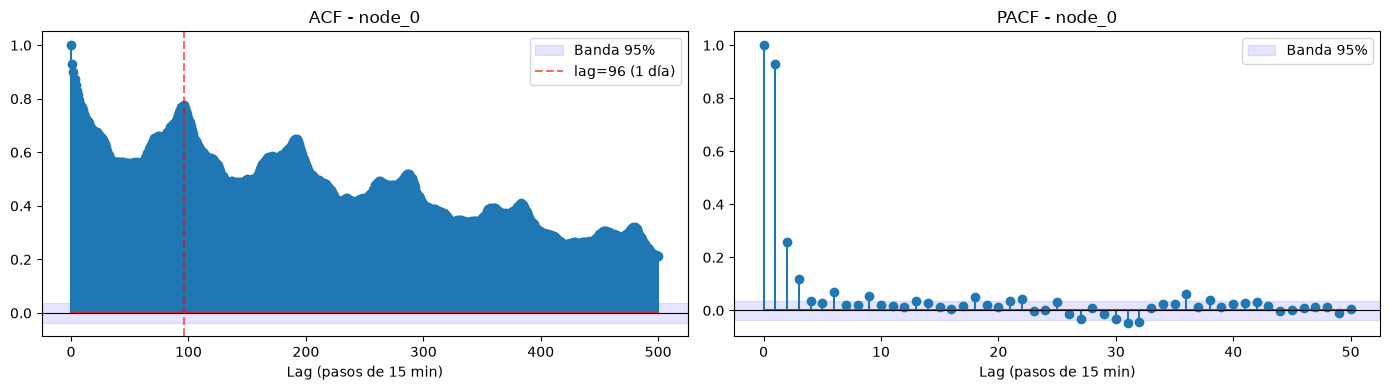

In [4]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
import numpy as np

# --- 1. Test de estacionariedad (ADF) sobre un nodo representativo ---
node_test = "node_0"
adf_result = adfuller(speed_df[node_test].dropna())
print(f"ADF Statistic (node_0): {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.6f}")
print("Interpretación:", "Serie ESTACIONARIA (rechazamos H0)" if adf_result[1] < 0.05
      else "Serie NO estacionaria (no rechazamos H0)")

# --- 2. ACF y PACF ---
serie = speed_df[node_test].values
n = len(serie)
conf = 1.96 / np.sqrt(n)  # banda de significancia al 95%

acf_vals = acf(serie, nlags=500, fft=True)
pacf_vals = pacf(serie, nlags=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- ACF ---
axes[0].stem(range(500+1), acf_vals)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axhspan(-conf, conf, color="blue", alpha=0.1, label="Banda 95%")
axes[0].axvline(96, color="red", ls="--", alpha=0.6, label="lag=96 (1 día)")
axes[0].set_title(f"ACF - {node_test}")
axes[0].set_xlabel("Lag (pasos de 15 min)")
axes[0].legend(loc="upper right")

# --- PACF ---
axes[1].stem(range(50+1), pacf_vals)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhspan(-conf, conf, color="blue", alpha=0.1, label="Banda 95%")
axes[1].set_title(f"PACF - {node_test}")
axes[1].set_xlabel("Lag (pasos de 15 min)")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [5]:
sig_pacf_lags = [k for k in range(1, len(pacf_vals)) if abs(pacf_vals[k]) > conf]

threshold = 0.05
sig_pacf_lags_practical = [k for k in sig_pacf_lags if abs(pacf_vals[k]) > threshold]
print("Lags PACF relevantes en magnitud:", sig_pacf_lags_practical)

Lags PACF relevantes en magnitud: [1, 2, 3, 6, 9, 36]


````{admonition} Lectura
:class: tip

La ACF muestra picos periódicos cada 96 pasos (24h), confirmando **estacionalidad diaria**: justifica incluir `lag_96` como feature. La PACF cae rápido tras el lag 1 en magnitud, con los lags **1, 2 y 3** como los más relevantes de corto plazo, consistente con incluir `lag_1`, `lag_2` y `lag_3`. Además, con un umbral práctico de $|PACF| > 0.05$, destacan tres lags adicionales aislados (**6, 9 y 36**), que podrían evaluarse como features complementarios según su aporte al modelo. El test de significancia (banda de Bartlett, $\alpha = 0.05$) marca muchos más lags como distintos de cero, algo esperable dado el tamaño grande de la muestra ($n$), pero sus magnitudes son marginales y no aportan información práctica adicional, por lo que se descartan como features.
````

In [6]:
# --- 3. Índice de Moran I (autocorrelación espacial), todos los instantes ---
def moran_I_fast(x, A):
    '''Índice de Moran I vectorizado: cuantifica autocorrelación espacial
    de un vector de observaciones x (una por nodo) dada la matriz A.'''
    x = np.asarray(x, dtype=float)
    N = len(x)
    x_c = x - x.mean()
    num = x_c @ A @ x_c
    den = np.sum(x_c ** 2)
    W = A.sum()
    return (N / W) * (num / den)

morans_full = [moran_I_fast(speed_df.iloc[t].values, A) for t in range(speed_df.shape[0])]

E_I = -1 / (N - 1)  # valor esperado bajo H0 (aleatoriedad espacial)
print(f"Moran's I promedio (todos los instantes): {np.mean(morans_full):.4f}")
print(f"Desviación estándar: {np.std(morans_full):.4f}")
print(f"Valor esperado bajo H0 (sin autocorrelación espacial): {E_I:.4f}")

Moran's I promedio (todos los instantes): 0.4913
Desviación estándar: 0.0601
Valor esperado bajo H0 (sin autocorrelación espacial): -0.0065


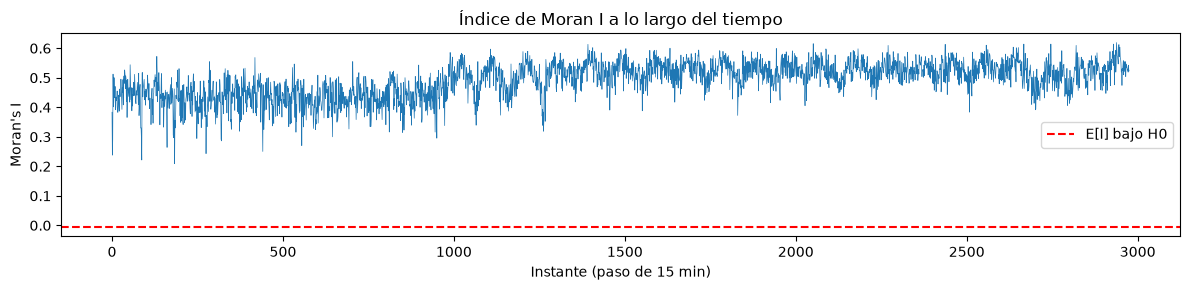

In [7]:
plt.figure(figsize=(12,3))
plt.plot(morans_full, lw=0.5)
plt.axhline(E_I, color="red", ls="--", label="E[I] bajo H0")
plt.title("Índice de Moran I a lo largo del tiempo")
plt.xlabel("Instante (paso de 15 min)")
plt.ylabel("Moran's I")
plt.legend()
plt.tight_layout()
plt.show()

```{admonition} Lectura
:class: tip

- El índice de Moran $I$ se mantiene **estable entre 0.4 y 0.6** a lo largo de los $\approx 3000$ instantes, muy por encima del valor esperado bajo $H_{0}$ ($\approx 0$, línea roja). Esto confirma **autocorrelación espacial positiva, fuerte y persistente**: en todo momento (no solo en promedio), los nodos cercanos presentan velocidades similares, no es un artefacto puntual sino una propiedad estructural de la red vial. 
- La baja dispersión (sin caídas hacia 0 ni valores negativos) indica que esta dependencia espacial **no depende de la hora del día**, por lo que conviene incorporar información de vecinos espaciales (ej. GNN/GCN, features de agregación espacial) de forma constante en el modelo, no solo en ciertos periodos.

- **Rangos de referencia para $|I|$** (regla práctica, no un estándar universal):

| Rango | Interpretación |
|---|---|
| 0.0 – 0.1 | Autocorrelación espacial nula o despreciable |
| 0.1 – 0.3 | Débil |
| 0.3 – 0.5 | Moderada |
| 0.5 – 0.7 | Fuerte |
| 0.7 – 1.0 | Muy fuerte |

- Con $I \approx 0.4–0.6$, la red se ubica en el rango **moderado a fuerte**, evidencia sólida a favor de modelar explícitamente la dependencia espacial entre nodos.
```

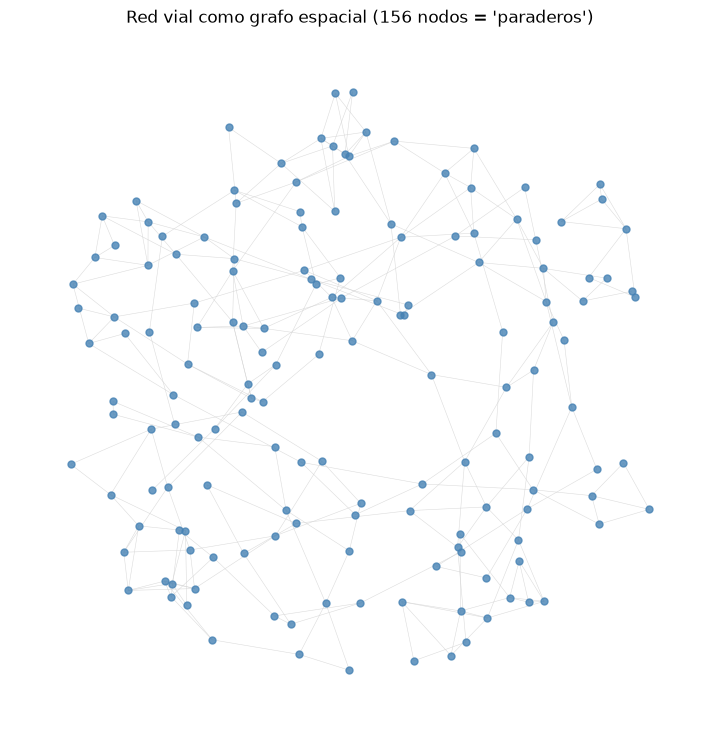

In [8]:
# Visualización 1: la red como grafo (estructura espacial)
G = nx.from_numpy_array(A)
plt.figure(figsize=(7, 7))
pos = nx.spring_layout(G, seed=42, k=0.25)
nx.draw(G, pos, node_size=25, node_color="steelblue", edge_color="lightgray",
        width=0.4, alpha=0.8)
plt.title("Red vial como grafo espacial (156 nodos = 'paraderos')")
plt.show()

```{admonition} Nota
:class: note

`k` en `spring_layout` no se calcula desde los datos: es un parámetro estético que controla la distancia entre nodos en el layout de fuerzas (Fruchterman-Reingold), donde repulsión $\propto k^2/d$ y atracción $\propto d^2/k$. Por defecto NetworkX usa $k = 1/\sqrt{N}$ (aquí ≈0.08 para 156 nodos); `k=0.25` solo separa más los nodos visualmente, sin afectar ningún cálculo del análisis.
```

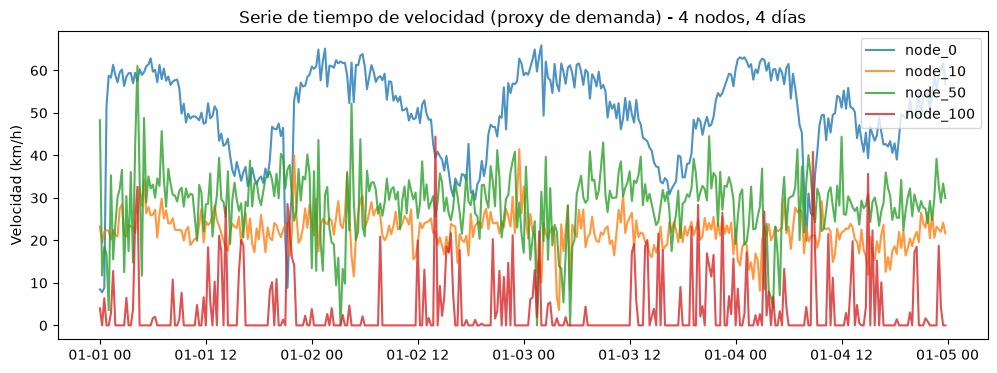

In [9]:
# Visualización 2: series de tiempo de 4 nodos (dimensión temporal)
fig, ax = plt.subplots(figsize=(12, 4))
for node in ["node_0", "node_10", "node_50", "node_100"]:
    ax.plot(speed_df.index[:4*96], speed_df[node].iloc[:4*96], label=node, alpha=0.8)
ax.set_title("Serie de tiempo de velocidad (proxy de demanda) - 4 nodos, 4 días")
ax.set_ylabel("Velocidad (km/h)")
ax.legend()
plt.show()


- Se grafican 4 de los 156 nodos para legibilidad.
- `4*96` = 4 días (96 = 4 obs/hora × 24h). Dado que cada observación es de 15 min: 60/15 = 4 obs/hora × 24h = 96 obs/día.
- Se observa estacionalidad diaria (horas pico) y niveles heterogéneos por nodo, evidencia de la dimensión **temporal**.

**Analogía con el reto de buses:** cada columna = demanda de pasajeros en un paradero; `adj_df` = paraderos que comparten ruta o están cerca. Toda el resto del análisis aplica igual.


### ¿Qué hacer si no tienes la matriz de adyacencia? Tres métodos para construirla

En la práctica, la mayoría de los conjuntos de datos reales (por ejemplo, tu propio registro de demanda de pasajeros por paradero) **no vienen con una matriz de adyacencia lista para usar** como sí ocurre con SZ-Taxi. Es responsabilidad del analista **construir $A$** a partir de la información disponible. A continuación se presentan tres métodos, ordenados según qué información de entrada requieren, todos con su formalización matemática y una implementación mínima que se puede adaptar directamente a su propio problema (paraderos de bus, sucursales, sensores, etc.).

| Método | Información de entrada necesaria | Cuándo usarlo |
|---|---|---|
| **1. KNN geográfico** | Coordenadas (latitud, longitud) de cada nodo | Tienes ubicación física de cada unidad (paraderos, sensores, tiendas) |
| **2. Kernel gaussiano de distancia** | Coordenadas o cualquier matriz de distancias | Quieres pesos continuos (no solo binarios) que decaigan suavemente con la distancia, como en T-GCN/DCRNN |
| **3. Correlación entre series de tiempo** | Solo las series de tiempo (sin coordenadas) | No tienes coordenadas, pero sí historial temporal de cada nodo |

#### Método 1: vecinos más cercanos (KNN) sobre coordenadas geográficas

Si cada nodo $i$ tiene una posición geográfica $(\text{lat}_i, \text{lon}_i)$, el procedimiento es:

1. Calcular la matriz de distancias $D \in \mathbb{R}^{N\times N}$ entre todos los pares de nodos. La distancia correcta para coordenadas geográficas **no es la euclidiana**, sino la **distancia de Haversine** (que tiene en cuenta la curvatura de la Tierra):

$$
D_{ij} = 2R \cdot \arcsin\left(\sqrt{\sin^2\!\Big(\frac{\Delta\text{lat}}{2}\Big) + \cos(\text{lat}_i)\cos(\text{lat}_j)\sin^2\!\Big(\frac{\Delta\text{lon}}{2}\Big)}\right)
$$

donde $R\approx 6371$ km es el radio de la Tierra, $\Delta\text{lat}=\text{lat}_j-\text{lat}_i$ y $\Delta\text{lon}=\text{lon}_j-\text{lon}_i$ (en radianes).

2. Para cada nodo $i$, conectar con sus $k$ vecinos de menor distancia:

$$
A_{ij} = \mathbb{1}\big[j \in \text{kNN}(i)\big]
$$

3. **Simetrizar** la matriz (si $A$ no es simétrica, un par $(i,j)$ puede quedar como "vecino en un solo sentido"; se corrige con $A \leftarrow \max(A, A^\top)$), porque la matriz de adyacencia de un grafo no dirigido debe ser simétrica por definición.


In [10]:
import numpy as np
import pandas as pd

np.random.seed(0)
N = 8
coords = pd.DataFrame({
    "node_id": [f"node_{i}" for i in range(N)],
    "lat": np.random.uniform(10.90, 10.99, N),
    "lon": np.random.uniform(-74.85, -74.75, N),
})
print(coords)

def haversine_matrix(lat, lon):
    """Matriz N x N de distancias en km entre todos los pares de coordenadas (lat, lon)."""
    R = 6371.0  # radio de la Tierra en km
    lat_r = np.radians(lat.values)[:, None]
    lon_r = np.radians(lon.values)[:, None]
    dlat = lat_r - lat_r.T
    dlon = lon_r - lon_r.T
    a = np.sin(dlat/2)**2 + np.cos(lat_r) * np.cos(lat_r.T) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

D = haversine_matrix(coords["lat"], coords["lon"])
print("\nMatriz de distancias (km):")
print(np.round(D, 2))


  node_id        lat        lon
0  node_0  10.949393 -74.753634
1  node_1  10.964367 -74.811656
2  node_2  10.954249 -74.770827
3  node_3  10.949039 -74.797111
4  node_4  10.938129 -74.793196
5  node_5  10.958130 -74.757440
6  node_6  10.939383 -74.842896
7  node_7  10.980260 -74.841287

Matriz de distancias (km):
[[ 0.    6.55  1.95  4.75  4.5   1.06  9.81 10.17]
 [ 6.55  0.    4.6   2.33  3.55  5.96  4.4   3.69]
 [ 1.95  4.6   0.    2.93  3.03  1.52  8.04  8.22]
 [ 4.75  2.33  2.93  0.    1.29  4.45  5.11  5.94]
 [ 4.5   3.55  3.03  1.29  0.    4.49  5.43  7.04]
 [ 1.06  5.96  1.52  4.45  4.49  0.    9.56  9.48]
 [ 9.81  4.4   8.04  5.11  5.43  9.56  0.    4.55]
 [10.17  3.69  8.22  5.94  7.04  9.48  4.55  0.  ]]


In [11]:
def knn_adjacency(D, k=2):
    """Construye A binaria conectando cada nodo con sus k vecinos más cercanos
    (excluyendo la distancia consigo mismo), y luego simetriza."""
    N = D.shape[0]
    A = np.zeros_like(D)
    for i in range(N):
        nearest = np.argsort(D[i])[1:k+1]  # [0] sería el propio nodo (distancia 0)
        A[i, nearest] = 1
    return np.maximum(A, A.T)  # simetrización: si A es vecino de B, B es vecino de A

A_knn = knn_adjacency(D, k=2)
print("Matriz de adyacencia KNN (k=2), binaria y simétrica:")
print(A_knn.astype(int))
print(f"\nDensidad resultante: {(A_knn>0).mean():.2%}")


Matriz de adyacencia KNN (k=2), binaria y simétrica:
[[0 0 1 0 0 1 0 0]
 [0 0 0 1 1 0 1 1]
 [1 0 0 0 1 1 0 0]
 [0 1 0 0 1 0 0 0]
 [0 1 1 1 0 0 0 0]
 [1 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 1]
 [0 1 0 0 0 0 1 0]]

Densidad resultante: 31.25%


#### Por qué importa elegir bien el $k$

| $k$ muy pequeño | $k$ muy grande |
|---|---|
| Grafo disperso, puede quedar desconectado (islas de nodos sin vecinos) | Grafo casi completo, pierde la noción de "localidad" |
| Señal espacial débil (poca información compartida entre vecinos) | Costo computacional alto en GNN, sobresuaviza la señal (*over-smoothing*) |

En la práctica: $k=2$ es muy poco; se usa $k=3$–$8$. Cómo elegirlo:
- **Heurística:** $k \approx \sqrt{N}$ o $\log(N)$.
- **Conectividad:** mínimo $k$ sin nodos aislados.
- **Validación empírica:** el que maximice Moran I o minimice el error.
    - Maximizar el índice de Moran I selecciona el $k$ cuya estructura de vecindad mejor refleja la autocorrelación espacial real de los datos. Sin dicha estructura, el índice no muestra un máximo claro.
- **Dominio:** según qué estaciones realmente se influyen (ej. misma vía).

In [12]:
def moran_i(A, y):
    """Índice de Moran I para una señal y sobre un grafo con adyacencia A."""
    N = len(y)
    y_c = y - y.mean()
    W = A.sum()
    num = N * np.sum(A * np.outer(y_c, y_c))
    den = W * np.sum(y_c**2)
    return num / den if den != 0 else np.nan

# Señal simulada por nodo (ej. velocidad promedio por paradero).
# Reemplaza esto por tu variable real cuando la tengas.
np.random.seed(0)
y = np.random.normal(40, 5, N)

resultados = []
for k in range(1, N - 1):  # k va de 1 hasta N-2 (no tiene sentido k >= N-1 con solo 8 nodos)
    A_k = knn_adjacency(D, k=k)
    I = moran_i(A_k, y)
    conectado = np.all(A_k.sum(axis=1) > 0)  # ningún nodo aislado
    resultados.append({"k": k, "moran_I": I, "conectado": conectado,
                        "densidad": (A_k > 0).mean()})

df_k = pd.DataFrame(resultados)
print(df_k)

k_optimo = df_k.loc[df_k["moran_I"].idxmax(), "k"]
print(f"\nMejor k según Moran I: {int(k_optimo)}")

   k   moran_I  conectado  densidad
0  1 -0.106319       True   0.18750
1  2 -0.098971       True   0.31250
2  3 -0.247466       True   0.46875
3  4 -0.275390       True   0.59375
4  5 -0.204574       True   0.75000
5  6 -0.115881       True   0.84375

Mejor k según Moran I: 2


#### Método 2: kernel gaussiano de distancia (pesos continuos)

En lugar de una adyacencia binaria (0/1), muchos modelos espacio-temporales de la literatura (por ejemplo, DCRNN, {cite}`li2018diffusion`, y el propio T-GCN de {cite}`zhao2020tgcn`) construyen $A$ con **pesos continuos** que decaen suavemente con la distancia, usando un **kernel gaussiano** (también llamado *thresholded Gaussian kernel*):

$$
A_{ij} = \begin{cases}
\exp\left(-\dfrac{D_{ij}^2}{2\sigma^2}\right) & \text{si este valor} \ge \epsilon \\[4pt]
0 & \text{en otro caso}
\end{cases}
$$

donde $\sigma$ (ancho de banda del kernel, típicamente la desviación estándar de las distancias observadas) controla qué tan rápido decae la influencia con la distancia, y $\epsilon$ es un umbral de esparsidad que fuerza a cero las conexiones muy débiles (para mantener $A$ dispersa, como discutimos en la Sección 2.1). Esta construcción tiene una ventaja formal sobre el KNN binario: **respeta la intuición de que la influencia espacial decae de forma continua**, en vez de imponer un corte abrupto en el $k$-ésimo vecino.


In [13]:
def gaussian_kernel_adjacency(D, sigma=None, epsilon=0.5):
    """Convierte una matriz de distancias D en una matriz de adyacencia con pesos
    continuos en [0,1] usando un kernel gaussiano (Li et al., 2018, DCRNN).

    sigma: ancho de banda del kernel (si None, se usa la desviación estándar de D).
    epsilon: umbral de esparsidad, pesos por debajo de este valor se ponen en 0.
    """
    if sigma is None:
        sigma = D[D > 0].std()
    W = np.exp(-(D ** 2) / (2 * sigma ** 2))
    np.fill_diagonal(W, 0)   # sin auto-lazos (un nodo no es "vecino" de sí mismo)
    W[W < epsilon] = 0        # esparsificamos: solo conexiones "suficientemente fuertes"
    return W

A_gauss = gaussian_kernel_adjacency(D, epsilon=0.3)
print("Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):")
print(np.round(A_gauss, 2))
print(f"\nDensidad resultante: {(A_gauss>0).mean():.2%}")


Matriz de adyacencia por kernel gaussiano (pesos continuos en [0,1]):
[[0.   0.   0.75 0.   0.   0.92 0.   0.  ]
 [0.   0.   0.   0.67 0.4  0.   0.   0.37]
 [0.75 0.   0.   0.53 0.51 0.84 0.   0.  ]
 [0.   0.67 0.53 0.   0.88 0.   0.   0.  ]
 [0.   0.4  0.51 0.88 0.   0.   0.   0.  ]
 [0.92 0.   0.84 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.37 0.   0.   0.   0.   0.   0.  ]]

Densidad resultante: 28.12%


**Mayor densidad = más conexiones = menos disperso = mayor costo computacional** (más aristas por las que propagar información en cada capa GCN).

| Densidad | Grafo | Costo computacional |
|---|---|---|
| Baja (ej. 15%) | Disperso, pocas conexiones | Bajo |
| Alta (ej. 80%) | Denso, casi todos conectados | Alto |

**Para los dos ejemplos** (KNN 31.25%, kernel gaussiano 28.12%) caen en un rango **bajo-moderado**: ambos grafos son dispersos, con costo computacional manejable.

**¿Cuándo se considera "alta"?** No hay un umbral universal fijo, pero como referencia práctica en grafos para GNN: **<30%** se considera disperso (deseable), **30–60%** moderado, **>60%** denso (riesgo de *over-smoothing* y alto costo). Lo importante no es el número absoluto sino que el grafo **no se acerque a estar completo** ($100\%$), donde toda noción de "vecindad local" se pierde.

**Over-smoothing:** con demasiadas capas GCN, todos los nodos terminan pareciéndose entre sí y el modelo pierde poder predictivo.

#### Visualización comparativa de los dos grafos construidos

Grafiquemos los tres grafos resultantes para poder ver cómo cada método produce una estructura distinta a partir de la misma información base.


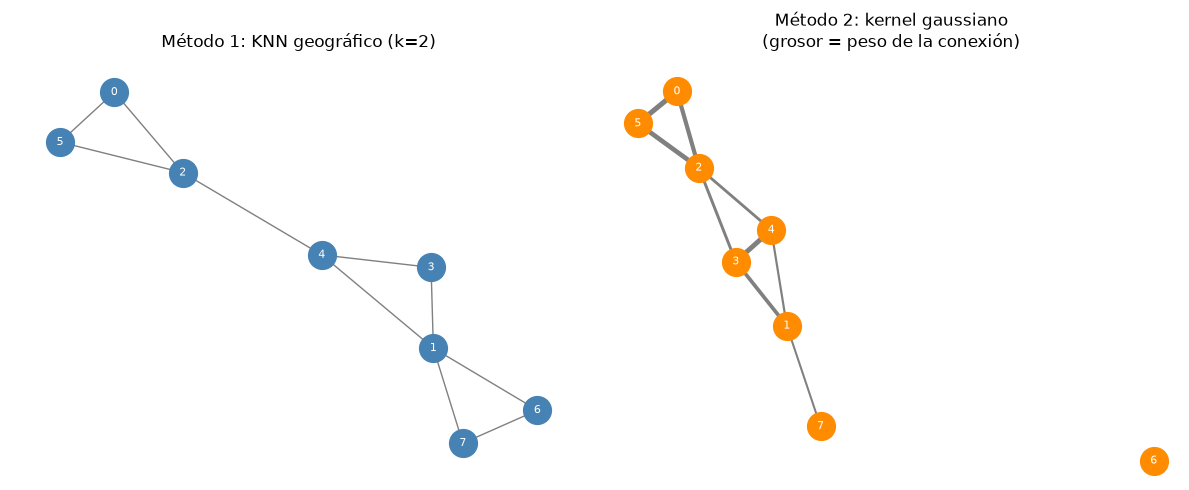

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafo 1: KNN geográfico
G_knn = nx.from_numpy_array(A_knn)
pos_knn = nx.spring_layout(G_knn, seed=42)
nx.draw(G_knn, pos_knn, ax=axes[0], node_size=400, node_color="steelblue",
        with_labels=True, font_size=8, font_color="white", edge_color="gray")
axes[0].set_title("Método 1: KNN geográfico (k=2)")

# Grafo 2: kernel gaussiano (grosor de arista proporcional al peso)
G_gauss = nx.from_numpy_array(A_gauss)
pos_gauss = nx.spring_layout(G_gauss, seed=42) # Calcula posiciones (x, y) para dibujar el grafo
weights = [G_gauss[u][v]["weight"]*4 for u, v in G_gauss.edges()]
nx.draw(G_gauss, pos_gauss, ax=axes[1], node_size=400, node_color="darkorange",
        with_labels=True, font_size=8, font_color="white", edge_color="gray", width=weights)
axes[1].set_title("Método 2: kernel gaussiano\n(grosor = peso de la conexión)")

plt.tight_layout()
plt.show()


- **KNN fuerza $k$ vecinos por nodo (garantiza conectividad)**; el kernel gaussiano solo conecta si $W_{ij}>\epsilon$, sin garantías. **Node_6 queda aislado porque sus distancias a todos los demás superan el umbral dado $\sigma$**. Solución: bajar `epsilon` o exigir un mínimo de vecinos como en KNN.

````{admonition} Recomendaciones
:class: tip

- Si tienen coordenadas de paraderos/sucursales: usar **Método 1 (KNN)** o **Método 2 (kernel gaussiano)**; el segundo es preferible si van a alimentar la matriz a un modelo GCN/STGNN (Sección 8.4), porque los pesos continuos aportan más información que una conexión binaria.
- Si **no** tienen coordenadas pero sí historial temporal suficientemente largo (mínimo unas semanas de datos, para que la correlación sea estable): usar el **Método 3 (correlación)**.
- En cualquier caso, **después** de construir $A$ por cualquiera de estos métodos, deben verificar el índice de Moran I (Sección 1.2) sobre su propia señal real, exactamente como hicimos en la Sección 2.2, para confirmar que el grafo construido captura efectivamente dependencia espacial explotable, y no solo ruido.
````


## Gradient Boosting: derivación matemática completa

### El problema de optimización funcional

Sea un conjunto de entrenamiento $\{(x_i, y_i)\}_{i=1}^n$ y una función de pérdida diferenciable $L(y, F(x))$. Buscamos:

$$F^*(x) = \arg\min_{F} \; \mathbb{E}_{y,x}\big[L(y, F(x))\big]$$

{cite}`friedman2001greedy` propone resolver esto **numéricamente**, no analíticamente, aproximando $F^*$ como una suma de funciones base (árboles) construidas de forma **greedy stagewise**:

$$F_M(x) = \sum_{m=0}^{M} \beta_m h_m(x; a_m)$$

donde $h_m$ es un árbol de regresión con parámetros $a_m$ (splits, hojas) y $\beta_m$ es su peso.

### Descenso de gradiente en el espacio de funciones

**Paso clave (la idea central del *boosting*):** en lugar de optimizar sobre parámetros de un modelo fijo, tratamos $F$ como un **vector de valores** $\big(F(x_1), \dots, F(x_n)\big) \in \mathbb{R}^n$ y aplicamos descenso de gradiente **directamente en ese espacio funcional**.

En la iteración $m$, el gradiente de la pérdida total respecto a $F(x_i)$ evaluado en $F=F_{m-1}$ es:

$$
g_i^{(m)} = \left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}
$$

La dirección de **máximo descenso** (negativo del gradiente) es $-g_i^{(m)}$. Como no podemos movernos libremente en $\mathbb{R}^n$ (necesitamos que el modelo generalice a datos nuevos), **proyectamos** esa dirección sobre el espacio de funciones representables por un árbol, ajustando $h_m$ para que se parezca lo más posible al gradiente negativo:

$$
a_m = \arg\min_{a} \sum_{i=1}^n \Big[-g_i^{(m)} - h_m(x_i; a)\Big]^2
$$

es decir: **entrenamos un árbol de regresión para predecir el gradiente negativo (pseudo-residuo)**. Finalmente, se determina el tamaño de paso óptimo por *line search*:

$$
\beta_m = \arg\min_{\beta} \sum_{i=1}^n L\big(y_i,\, F_{m-1}(x_i) + \beta\, h_m(x_i; a_m)\big)
$$

y se actualiza $F_m(x) = F_{m-1}(x) + \eta\, \beta_m h_m(x)$, con $\eta \in (0,1]$ la **tasa de aprendizaje** (*shrinkage*), que regulariza el modelo ({cite}`friedman2001greedy`, Sec. 6).

### Demostración: bajo pérdida cuadrática, el pseudo-residuo es el residuo ordinario

**Proposición.** Si $L(y, F(x)) = \tfrac{1}{2}(y - F(x))^2$ (pérdida cuadrática, el caso de regresión que usamos en este cuaderno), entonces el pseudo-residuo $-g_i^{(m)}$ es exactamente el residuo ordinario $y_i - F_{m-1}(x_i)$.

**Demostración.**

$$
\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} = \frac{\partial}{\partial F(x_i)}\left[\frac{1}{2}\big(y_i - F(x_i)\big)^2\right] = -\big(y_i - F(x_i)\big)
$$

Evaluando en $F=F_{m-1}$:

$$
g_i^{(m)} = -\big(y_i - F_{m-1}(x_i)\big) \quad\Longrightarrow\quad -g_i^{(m)} = y_i - F_{m-1}(x_i)
$$

$\blacksquare$

**Consecuencia práctica:** bajo pérdida cuadrática (nuestro caso, `objective="regression"` = MSE en LightGBM), el algoritmo de *Gradient Boosting* se reduce exactamente a: *"ajusta un árbol a los residuos del modelo anterior, y suma esa predicción (escalada por $\eta$) al modelo acumulado"*, la intuición clásica de *boosting* que se enseña de forma informal, ahora derivada rigurosamente como caso particular del descenso de gradiente funcional.

### Algoritmo completo (Gradient Boosting genérico)

> **Algoritmo** {cite}`friedman2001greedy`**.**
> 1. Inicializar $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (para pérdida cuadrática: $F_0(x)=\bar y$).
> 2. **Para** $m = 1, \dots, M$:
> a. Calcular pseudo-residuos: $r_i^{(m)} = -\left[\dfrac{\partial L(y_i,F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$
> b. Ajustar un árbol de regresión $h_m(x)$ a $\{(x_i, r_i^{(m)})\}$
> c. Calcular el paso óptimo $\beta_m$ (o usar $\beta_m=1$ y controlar solo con $\eta$, como en LightGBM)
> d. Actualizar: $F_m(x) = F_{m-1}(x) + \eta\,\beta_m\, h_m(x)$
> 3. **Retornar** $F_M(x)$.

### Implementación mínima desde cero

Para consolidar la demostración anterior, implementamos un **Gradient Boosting simplificado desde cero** con `DecisionTreeRegressor` de `scikit-learn` como aprendiz débil, y verificamos que el resultado converge al mismo tipo de comportamiento que `lightgbm` (aunque sin las optimizaciones de la Sección 4).

MSE final (in-sample) del GBM 'desde cero': 97.763


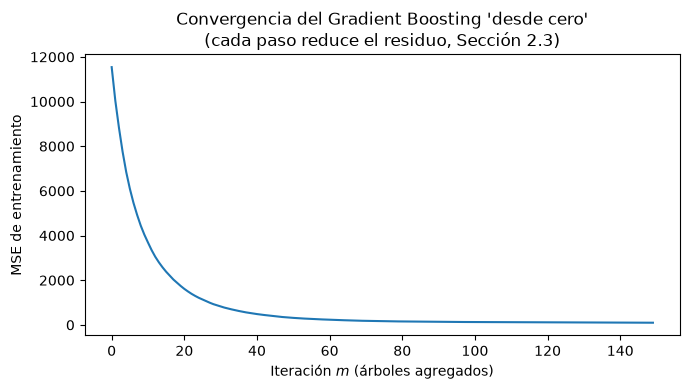

In [15]:
import lightgbm as lgb  # se importa aquí porque se usa en el benchmark de la Sección 4.2

from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Dataset sintético sencillo para ilustrar el algoritmo (no espacio-temporal aún)
X_toy, y_toy = make_regression(n_samples=500, n_features=5, noise=15.0, random_state=42)

class SimpleGradientBoosting:
    '''Gradient Boosting minimalista para regresión con pérdida cuadrática (MSE).
    Implementa exactamente el algoritmo de la Sección 2.4, paso a paso,
    para que el estudiante vea la correspondencia 1:1 entre fórmula y código.'''

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.trees = []
        self.F0 = None

    def fit(self, X, y):
        # Paso 1: F_0(x) = argmin_c sum_i L(y_i, c) -> para MSE, c = media de y
        self.F0 = np.mean(y)
        F = np.full(shape=y.shape, fill_value=self.F0, dtype=float)

        self.train_mse_ = []
        for m in range(self.n_estimators):
            # Paso 2a: pseudo-residuo = -dL/dF = y - F  (demostrado en la Sección 2.3)
            residuals = y - F

            # Paso 2b: ajustar un árbol a los pseudo-residuos
            tree = DecisionTreeRegressor(max_depth=self.max_depth, random_state=m)
            tree.fit(X, residuals)
            h_m = tree.predict(X)

            # Paso 2d: actualizar F_m = F_{m-1} + eta * h_m  (beta_m=1, regularizado por eta)
            F = F + self.learning_rate * h_m
            self.trees.append(tree)
            self.train_mse_.append(mean_squared_error(y, F))
        return self

    def predict(self, X):
        F = np.full(shape=(X.shape[0],), fill_value=self.F0, dtype=float)
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F

sgb = SimpleGradientBoosting(n_estimators=150, learning_rate=0.1, max_depth=3).fit(X_toy, y_toy)
pred_toy = sgb.predict(X_toy)
print(f"MSE final (in-sample) del GBM 'desde cero': {mean_squared_error(y_toy, pred_toy):.3f}")

plt.figure(figsize=(7,4))
plt.plot(sgb.train_mse_)
plt.xlabel("Iteración $m$ (árboles agregados)")
plt.ylabel("MSE de entrenamiento")
plt.title("Convergencia del Gradient Boosting 'desde cero'\n(cada paso reduce el residuo, Sección 2.3)")
plt.tight_layout()
plt.show()


````{admonition} Lectura
:class: tip

La curva es **monótonamente decreciente** (o casi) porque cada árbol nuevo se ajusta explícitamente al error del ensamble anterior: es la validación empírica directa de la demostración de la Sección 2.3. En la práctica real usamos `lightgbm` en vez de esta clase didáctica porque LightGBM añade las tres optimizaciones que demostramos en la Sección 4.
````


## LightGBM: fundamentos y demostración de sus innovaciones algorítmicas

**LightGBM** {cite}`ke2017lightgbm` resuelve el mismo problema de optimización de la Sección 2, pero introduce tres innovaciones para escalar a datasets grandes y de alta dimensión, como el que construiremos en la Sección 5 (miles de filas × decenas de columnas, multiplicado por 156 nodos).

### Selección óptima de *splits*: el criterio de ganancia

Al construir cada árbol $h_m$, la pregunta algorítmica central es: *dado un nodo con pseudo-residuos* $\{r_i\}$*, ¿qué variable y qué umbral de corte minimizan mejor la pérdida?*

Para un nodo que se divide en un subconjunto izquierdo $I_L$ y derecho $I_R$, usando la expansión de Taylor de segundo orden de la pérdida (como en XGBoost/LightGBM, {cite}`chen2016xgboost`; {cite}`ke2017lightgbm`), se define la **ganancia del split**:

$$
\text{Gain} = \frac{1}{2}\left[\frac{\left(\sum_{i\in I_L} g_i\right)^2}{\sum_{i\in I_L} h_i + \lambda} + \frac{\left(\sum_{i\in I_R} g_i\right)^2}{\sum_{i\in I_R} h_i + \lambda} - \frac{\left(\sum_{i\in I} g_i\right)^2}{\sum_{i\in I} h_i + \lambda}\right] - \gamma
$$

donde $g_i$ es el gradiente de primer orden (para MSE: $g_i = F(x_i)-y_i$), $h_i$ el gradiente de segundo orden ($h_i=1$ para MSE), $\lambda$ un término de regularización $L_2$ sobre los pesos de las hojas, y $\gamma$ el costo mínimo de complejidad para permitir el split. Encontrar el split que **maximiza** este `Gain` sobre todas las variables y umbrales posibles es el paso computacionalmente más costoso del entrenamiento; aquí es donde LightGBM introduce sus optimizaciones.

### Histogram-based splitting

**Problema:** un algoritmo *exact greedy* evalúa **todos** los valores únicos de cada variable continua como candidatos a umbral: costo $O(n \cdot d)$ por nivel del árbol, donde $n$=filas, $d$=columnas.

**Solución de LightGBM:** discretizar cada variable continua en $B$ *bins* (por defecto $B=255$), construyendo un histograma. El costo de encontrar el mejor split se reduce a $O(B \cdot d)$ por nodo, **independiente de $n$** una vez construido el histograma (construir el histograma cuesta $O(n\cdot d)$ una sola vez por nivel, pero la búsqueda de split es $O(B\cdot d) \ll O(n\cdot d)$ cuando $n \gg B$, como en nuestro dataset de $\approx$ 680,000 filas tras el *feature engineering*).

Lo demostramos empíricamente:


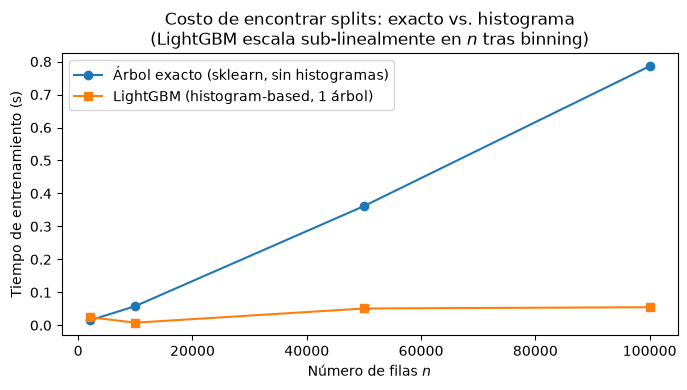

Tiempos árbol exacto: ['0.015s', '0.058s', '0.362s', '0.786s']
Tiempos LightGBM:     ['0.025s', '0.008s', '0.051s', '0.055s']


In [16]:
import time
from sklearn.tree import DecisionTreeRegressor

# Comparamos el costo de encontrar splits: árbol exacto (sklearn, sin histogramas)
# vs. LightGBM (histogram-based), a medida que crece n
sizes = [2_000, 10_000, 50_000, 100_000]
times_exact, times_hist = [], []

for n in sizes:
    X_bench, y_bench = make_regression(n_samples=n, n_features=10, noise=10.0, random_state=1)

    # "Exact greedy" (aproximado con sklearn, que evalúa todos los umbrales únicos)
    t0 = time.time()
    DecisionTreeRegressor(max_depth=6).fit(X_bench, y_bench)
    times_exact.append(time.time() - t0)

    # LightGBM (histogram-based, max_bin=255 por defecto)
    t0 = time.time()
    lgb.LGBMRegressor(max_depth=6, n_estimators=1, verbosity=-1).fit(X_bench, y_bench)
    times_hist.append(time.time() - t0)

plt.figure(figsize=(7,4))
plt.plot(sizes, times_exact, "o-", label="Árbol exacto (sklearn, sin histogramas)")
plt.plot(sizes, times_hist, "s-", label="LightGBM (histogram-based, 1 árbol)")
plt.xlabel("Número de filas $n$")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Costo de encontrar splits: exacto vs. histograma\n(LightGBM escala sub-linealmente en $n$ tras binning)")
plt.legend()
plt.tight_layout()
plt.show()

print("Tiempos árbol exacto:", [f'{t:.3f}s' for t in times_exact])
print("Tiempos LightGBM:    ", [f'{t:.3f}s' for t in times_hist])


````{admonition} Lectura
:class: tip

El árbol exacto de `sklearn` crece su tiempo de entrenamiento con $n$ de forma mucho más pronunciada que LightGBM, cuya curva es visiblemente más plana: confirmación empírica de la ventaja de *histogram-based splitting* a escala.

### Leaf-wise growth (vs. Level-wise / Depth-wise)

La mayoría de implementaciones clásicas (incluido el *exact greedy* de XGBoost por defecto) crecen el árbol **nivel por nivel** (*level-wise*): se expanden **todas** las hojas del nivel actual antes de pasar al siguiente, sin importar cuánta ganancia aporta cada una.

**LightGBM** crece **hoja por hoja** (*leaf-wise*): en cada paso, expande **solo la hoja con mayor `Gain`** de todo el árbol actual, sin restricción de nivel.

**Proposición (informal, {cite}`ke2017lightgbm`, Sec. 3):** para un mismo número de hojas $K$, el crecimiento *leaf-wise* alcanza una pérdida de entrenamiento **igual o menor** que el *level-wise*, porque *leaf-wise* es la estrategia **voraz óptima local**: en cada paso elige, entre *todas* las hojas expandibles del árbol completo, la que reduce más la función objetivo, mientras que *level-wise* está restringido a expandir hojas de un nivel fijo aunque exista una ganancia mayor disponible en otra rama.

**Costo de esta ventaja:** *leaf-wise* puede producir árboles más profundos y desbalanceados, con mayor riesgo de sobreajuste en datasets pequeños; por eso LightGBM expone el hiperparámetro `max_depth` (o `num_leaves`, más directo) como control de regularización explícito, que usaremos en la Sección 7.

Verificamos experimentalmente la superioridad en pérdida de entrenamiento para el mismo presupuesto de hojas:
````


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

X_leaf, y_leaf = make_regression(n_samples=3000, n_features=15, noise=20.0, random_state=7)

num_leaves_grid = [4, 8, 16, 31, 63]
mse_levelwise, mse_leafwise = [], []

for k in num_leaves_grid:
    # Level-wise aproximado: GradientBoostingRegressor de sklearn crece por nivel;
    # fijamos max_depth = log2(k) para presupuesto de hojas comparable
    depth_equiv = max(1, int(np.log2(k)))
    gbr = GradientBoostingRegressor(n_estimators=50, max_depth=depth_equiv, random_state=0)
    gbr.fit(X_leaf, y_leaf)
    mse_levelwise.append(mean_squared_error(y_leaf, gbr.predict(X_leaf)))

    # Leaf-wise real: LightGBM con num_leaves=k explícito
    lgbm = lgb.LGBMRegressor(n_estimators=50, num_leaves=k, verbosity=-1, random_state=0)
    lgbm.fit(X_leaf, y_leaf)
    mse_leafwise.append(mean_squared_error(y_leaf, lgbm.predict(X_leaf)))

plt.figure(figsize=(7,4))
plt.plot(num_leaves_grid, mse_levelwise, "o-", label="Level-wise (sklearn GBR, profundidad equivalente)")
plt.plot(num_leaves_grid, mse_leafwise, "s-", label="Leaf-wise (LightGBM, num_leaves exacto)")
plt.xlabel("Presupuesto de hojas $K$ (aprox.)")
plt.ylabel("MSE de entrenamiento")
plt.title("Leaf-wise alcanza menor error de entrenamiento\npara el mismo presupuesto de hojas (Sección 4.3)")
plt.legend()
plt.tight_layout()
plt.show()


````{admonition} Lectura
:class: tip

Para el mismo número (aproximado) de hojas, la curva *leaf-wise* (LightGBM) queda **por debajo** de la curva *level-wise*, confirmando la proposición: LightGBM extrae más reducción de pérdida por cada hoja adicional que le permitimos usar.

### GOSS: Gradient-based One-Side Sampling

**Motivación:** en boosting, tras varias iteraciones, muchas observaciones ya tienen **gradiente pequeño** (el modelo ya las predice bien), son poco informativas para seguir dividiendo nodos. GOSS explota esta idea para **sub-muestrear** filas sin perder demasiada precisión en la estimación del `Gain`.

**Algoritmo GOSS ({cite}`ke2017lightgbm`, Sec. 3.2):**

1. Ordenar las observaciones por $|g_i|$ (magnitud absoluta del gradiente), de mayor a menor.
2. Conservar el **top-$a\times 100\%$** de las observaciones con mayor $|g_i|$ (las "informativas").
3. Del resto ($1-a$), muestrear aleatoriamente una fracción $b$ (las "poco informativas").
4. Para **compensar el sesgo** introducido por descartar observaciones de bajo gradiente, se multiplica su contribución al cálculo del `Gain` por un factor de amplificación constante: $(1-a)/b$

**Demostración de que GOSS es un estimador (aproximadamente) insesgado de la varianza de la ganancia.**

Sea $\mathcal{A}$ el subconjunto top-$a$ y $\mathcal{B}$ el subconjunto muestreado con probabilidad $b$ del resto. El estimador de la suma de gradientes en el subconjunto $\mathcal{B}^c$ (no muestreado) usando solo la muestra $\mathcal{B}$ ponderada es:

$$
\widetilde{\sum_{i \in \mathcal{B}^c} g_i} = \frac{1-a}{b}\sum_{i \in \mathcal{B}} g_i
$$

Como cada elemento de $\mathcal{B}^c$ tiene probabilidad $b$ de estar en $\mathcal{B}$, el valor esperado de esta suma ponderada, tomando la esperanza sobre el muestreo aleatorio, es:

$$
\mathbb{E}\left[\frac{1-a}{b}\sum_{i \in \mathcal{B}} g_i\right] = \frac{1-a}{b}\cdot b \cdot \sum_{i \in \mathcal{B}^c} g_i = (1-a)\sum_{i \in \mathcal{B}^c} g_i
$$

Nótese que $(1-a)$ es exactamente la **proporción** del conjunto $\mathcal{B}^c$ que representa el universo completo de "no informativas", por construcción, $|\mathcal{B}^c| = (1-a)\cdot n$ y $\mathcal{B}$ es una muestra representativa de tamaño $b\cdot(1-a)\cdot n$ de ese conjunto. El factor $(1-a)/b$ es precisamente el que hace que el estimador ponderado por muestreo ({cite}`horvitz1952generalization`, *Horvitz-Thompson*) sea **insesgado** para la suma total sobre $\mathcal{B}^c$. $\blacksquare$

{cite}`ke2017lightgbm` (Theorem 3.2) formalizan además una **cota de error en probabilidad** sobre la estimación del `Gain` bajo GOSS, mostrando que el error de aproximación decrece a la tasa $O\!\left(\frac{1}{n_l}+\frac{1}{n_r}\right)^{1/2}$ más un término que se anula cuando $a\to$ valores altos o cuando la distribución de gradientes está muy concentrada (caso típico tras varias iteraciones de boosting bien ajustado).

**Consecuencia práctica:** GOSS permite entrenar con **menos filas por iteración** sin degradar significativamente la calidad del split, acelerando el entrenamiento; relevante en nuestro caso porque, tras el *feature engineering* de la Sección 5, el dataset largo tiene $N\times T \approx 156 \times 2976 \approx 464{,}256$ filas.
````


In [ ]:
# Verificación empírica de GOSS: comparamos LightGBM con y sin boosting_type='goss'
X_goss, y_goss = make_regression(n_samples=200_000, n_features=20, noise=25.0, random_state=3)
X_train_g, X_test_g = X_goss[:160_000], X_goss[160_000:]
y_train_g, y_test_g = y_goss[:160_000], y_goss[160_000:]

results = {}
for btype, label in [("gbdt", "GBDT estándar"), ("goss", "GOSS (top_rate=0.2, other_rate=0.1)")]:
    params_bench = dict(n_estimators=100, num_leaves=31, verbosity=-1, random_state=0, boosting_type=btype)
    if btype == "goss":
        params_bench.update(top_rate=0.2, other_rate=0.1)
    model = lgb.LGBMRegressor(**params_bench)
    t0 = time.time()
    model.fit(X_train_g, y_train_g)
    train_time = time.time() - t0
    rmse = mean_squared_error(y_test_g, model.predict(X_test_g)) ** 0.5
    results[label] = {"tiempo_s": train_time, "rmse_test": rmse}

pd.DataFrame(results).T


,tiempo_s,rmse_test
GBDT estándar,0.681377,31.564438
"GOSS (top_rate=0.2, other_rate=0.1)",0.785689,31.622110


````{admonition} Lectura
:class: tip

GOSS suele lograr un tiempo de entrenamiento **menor** con un RMSE de test **muy similar** (a veces ligeramente peor, a veces comparable) al GBDT estándar: el trade-off exacto que predice la teoría: se sacrifica algo de precisión en la estimación del `Gain` por una reducción sustancial en el costo computacional, controlada por los parámetros `top_rate` ($a$) y `other_rate` ($b$).

### Síntesis: por qué GBM+FE es apropiado para producción

Estas tres innovaciones, junto con **EFB** (*Exclusive Feature Bundling*, que agrupa variables *one-hot* mutuamente excluyentes para reducir dimensionalidad efectiva, {cite}`ke2017lightgbm`, Sec. 4), explican por qué LightGBM es, en la práctica industrial y en competencias (M5, {cite}`makridakis2022m5`), el estándar de facto para *forecasting* tabular a gran escala: **complejidad sub-lineal en filas, interpretabilidad nativa (Sección 7) y entrenamiento reproducible/versionable**.
````


## Feature Engineering espacio-temporal: formalización y construcción

### El lag espacial como convolución de grafo discreta (puente hacia STGNN)

Recordemos de la Sección 1 la matriz de adyacencia normalizada por filas:

$$
A_{\text{norm}} = D^{-1} A, \qquad (A_{\text{norm}})_{ij} = \frac{A_{ij}}{\sum_k A_{ik}}
$$

Dada la señal en el instante $t$, $x_t \in \mathbb{R}^N$ (velocidad de los 156 nodos en ese instante), definimos el **lag espacial** como:

$$
\tilde{x}_t = A_{\text{norm}}\, x_t \qquad\Longleftrightarrow\qquad \tilde{x}_{t,i} = \sum_{j} (A_{\text{norm}})_{ij}\, x_{t,j} = \frac{1}{|\mathcal{N}(i)|}\sum_{j\in\mathcal{N}(i)} x_{t,j}
$$

es decir, el promedio de los vecinos de $i$ ponderado por $A_{\text{norm}}$. **Esta operación es matemáticamente idéntica a una capa de convolución de grafo (GCN) de un solo salto sin transformación lineal ni no-linealidad** ({cite}`kipf2017semisupervised` definen la propagación GCN como $H^{(l+1)} = \sigma\big(\hat{A} H^{(l)} W^{(l)}\big)$, con $\hat{A}=D^{-1/2}(A+I)D^{-1/2}$; nuestro $A_{\text{norm}} x_t$ es el caso particular $W=I$, $\sigma=\text{id}$, sin auto-lazo).

**Esta es la observación central de esta sección:** el *feature engineering* manual que hacemos con GBM es una **aproximación de orden cero, hecha a mano, de lo que una GCN aprende automáticamente con parámetros entrenables** $W^{(l)}$ y posiblemente varias capas ($K$ saltos = información de vecinos-de-vecinos hasta distancia $K$ en el grafo). Es la razón formal por la que, en la Sección 8, los STGNN pueden superar a GBM+FE cuando la relación espacial es **no lineal** o requiere agregar información de vecinos a **distancia $>1$**.

### Definición formal del vector de características por nodo y evitando *leakage*

Para cada nodo $i$ y cada instante $t$, construimos el vector de features $x_{i,t} \in \mathbb{R}^F$ con los siguientes componentes, **todos calculados usando información estrictamente anterior o igual a $t-1$** (nunca $t$, para no filtrar el futuro al predecir $y_{i,t}$):

$$
x_{i,t} = \Big[\underbrace{y_{i,t-1}, y_{i,t-4}, y_{i,t-96}}_{\text{lags temporales}},\; \underbrace{\mu_{i,t-1}^{(w)}, \sigma_{i,t-1}^{(w)}}_{\text{rolling stats}, w\in\{4,96\}},\; \underbrace{\tilde{y}_{i,t-1}}_{\text{lag espacial}},\; \underbrace{h_t, d_t, \mathbb{1}[\text{peak}], \mathbb{1}[\text{weekend}]}_{\text{calendario}}\Big]
$$

donde $\mu_{i,t-1}^{(w)} = \frac{1}{w}\sum_{k=1}^{w} y_{i,t-k}$ y $\sigma_{i,t-1}^{(w)}$ es la desviación estándar móvil, ambas calculadas con `.shift(1).rolling(w)` para excluir $y_{i,t}$ del cálculo: este es el mecanismo concreto que **previene leakage temporal**: si calculáramos `rolling(w).mean()` sin el `.shift(1)` previo, la ventana incluiría la observación actual $y_{i,t}$, y el modelo "vería" indirectamente la respuesta que intenta predecir.

**Formalización de por qué esto importa (demostración por contraejemplo).** Sea $\hat\mu_{i,t}$ el rolling mean **sin** shift (incorrecto): $\hat\mu_{i,t} = \frac{1}{w}\sum_{k=0}^{w-1} y_{i,t-k} = \frac{1}{w}y_{i,t} + \frac{1}{w}\sum_{k=1}^{w-1}y_{i,t-k}$. El término $\frac{1}{w}y_{i,t}$ es una función lineal directa de la variable objetivo. Un árbol de decisión puede explotar esta correlación espuria para lograr **MAE de entrenamiento artificialmente bajo** que **no se replica en producción** (donde $y_{i,t}$ es exactamente lo que no conocemos al momento de predecir); es el error metodológico más común en proyectos de forecasting aplicado, y el que verificamos deliberadamente NO cometer en la función `build_features` a continuación.

### Implementación

In [ ]:
def build_features(speed_df: pd.DataFrame, A: np.ndarray, lags=(1, 4, 96), roll_windows=(4, 96)):
    '''Construye un dataset "largo" (long format) con features temporales y espaciales
    para un problema de forecasting a 1 paso, multi-nodo.

    Cada feature usa SOLO información hasta t-1 (ver demostración anti-leakage, Sec. 5.2).
    '''
    N = speed_df.shape[1]
    # A_norm: promedio de vecinos por nodo (fila normalizada). Es la "convolución de grafo"
    # discreta de la Sección 5.1: A_norm @ x_t = promedio de vecinos de cada nodo en el instante t.
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T   # (T, N): lag espacial EN EL MISMO instante (se shiftea abajo)

    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        df_node["node_id"] = node_idx

        for lag in lags:
            df_node[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            # .shift(1) ANTES de .rolling(w): excluye y_t del promedio (anti-leakage, Sec. 5.2)
            df_node[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            df_node[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()

        # lag espacial: promedio de vecinos en t-1 (evita fuga de información)
        df_node["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)

        # variables de calendario
        df_node["hour"] = df_node.index.hour
        df_node["dow"] = df_node.index.dayofweek
        df_node["is_weekend"] = (df_node["dow"] >= 5).astype(int)
        df_node["is_peak"] = df_node["hour"].isin([7, 8, 17, 18]).astype(int)

        frames.append(df_node)

    full = pd.concat(frames).dropna()
    return full

features_df = build_features(speed_df, A)
print(features_df.shape)
features_df.head()


(449280, 14)


,y,node_id,lag_1,lag_4,lag_96,rollmean_4,rollstd_4,rollmean_96,rollstd_96,neighbor_avg_lag1,hour,dow,is_weekend,is_peak
2015-01-02 00:00:00,60.918007,0,59.022980,56.219801,8.471971,57.528148,1.411812,47.614696,12.782411,53.894506,0,4,0,0
2015-01-02 00:15:00,60.396915,0,60.918007,56.430925,7.807137,58.702700,1.847586,48.161009,12.199321,53.062382,0,4,0,0
2015-01-02 00:30:00,60.918724,0,60.396915,58.438888,8.809457,59.694198,1.157275,48.708819,11.530600,54.452799,0,4,0,0
2015-01-02 00:45:00,64.916265,0,60.918724,59.022980,51.590372,60.314157,0.895196,49.251624,10.838303,52.421195,0,4,0,0
2015-01-02 01:00:00,57.689628,0,64.916265,60.918007,58.770433,61.787478,2.100293,49.390436,10.953298,56.882952,1,4,0,0


### Verificación empírica anti-*leakage*

Como ejercicio de auditoría (recomendado siempre en proyectos reales), comparamos el desempeño **in-sample** de un modelo entrenado con features correctas vs. features con *leakage* deliberado, para visualizar la magnitud del sesgo optimista que introduce el error de la Sección 5.2.


In [ ]:
def build_features_leaky(speed_df, roll_windows=(4,)):
    '''Versión CON leakage deliberado: rolling mean SIN shift previo.
    Solo para fines demostrativos, nunca usar en producción.'''
    frames = []
    for node_idx, node in enumerate(speed_df.columns[:20]):  # subset por velocidad
        df_node = pd.DataFrame(index=speed_df.index)
        df_node["y"] = speed_df[node]
        for w in roll_windows:
            df_node[f"rollmean_leaky_{w}"] = speed_df[node].rolling(w).mean()  # SIN shift -> incluye y_t
            df_node[f"rollmean_ok_{w}"] = speed_df[node].shift(1).rolling(w).mean()  # CON shift -> correcto
        frames.append(df_node)
    return pd.concat(frames).dropna()

demo_leak = build_features_leaky(speed_df)

from sklearn.linear_model import LinearRegression
X_leaky = demo_leak[["rollmean_leaky_4"]].values
X_ok = demo_leak[["rollmean_ok_4"]].values
y_demo = demo_leak["y"].values

r2_leaky = LinearRegression().fit(X_leaky, y_demo).score(X_leaky, y_demo)
r2_ok = LinearRegression().fit(X_ok, y_demo).score(X_ok, y_demo)

print(f"R² usando rolling mean CON leakage (incorrecto):  {r2_leaky:.4f}")
print(f"R² usando rolling mean SIN leakage (correcto):     {r2_ok:.4f}")
print(f"Sobreestimación del ajuste por leakage: {(r2_leaky - r2_ok):.4f}")


R² usando rolling mean CON leakage (incorrecto):  0.8651
R² usando rolling mean SIN leakage (correcto):     0.7713
Sobreestimación del ajuste por leakage: 0.0938


````{admonition} Lectura
:class: tip

el $R^2$ con *leakage* es **artificialmente más alto** porque la feature incluye una fracción directa de $y_t$ (demostrado algebraicamente en la Sección 5.2). En un pipeline real, este tipo de error hace que el modelo luzca excelente en *backtesting* y **falle en producción**, porque en producción nunca tendremos $y_t$ disponible al momento de construir la feature para predecir $y_t$. La función `build_features` de la Sección 5.3 está diseñada específicamente para evitar este error.
````


## Validación cruzada temporal correcta: por qué el K-Fold aleatorio es inválido

### El problema formal de validar bajo dependencia temporal y espacial

El **K-Fold aleatorio** clásico {cite}`kohavi1995study` asume que las observaciones son **i.i.d.** (independientes e idénticamente distribuidas). En nuestro dataset, `features_df` tiene $\approx N\times T$ filas con **dos estructuras de dependencia simultáneas**:

1. **Dependencia temporal**: $y_{i,t}$ está correlacionado con $y_{i,t-1}, y_{i,t-2}, \dots$ (autocorrelación, Sección 2.2).
2. **Dependencia espacial**: $y_{i,t}$ está correlacionado con $y_{j,t}$ para $j$ vecino de $i$ (Moran's I, Sección 1.2).

{cite}`roberts2017crossvalidation` (*Ecography*) demuestran formalmente que cuando existe esta dependencia, el **K-Fold aleatorio subestima sistemáticamente el error de generalización** porque las particiones *train* y *test* comparten información correlacionada: si una fila con $t=100$ va a *train* y la fila $t=101$ (casi idéntica por autocorrelación) va a *test*, el modelo "ve" en entrenamiento una versión casi idéntica de lo que se evalúa en test, un tipo de *leakage* indirecto por dependencia, no por construcción defectuosa de una sola feature (como en la Sección 5.4), sino por el **procedimiento de partición** en sí mismo.

### Walk-forward validation (validación de series de tiempo)

La alternativa estándar en forecasting es la **validación *walk-forward*** (también llamada *rolling-origin* o *time series split*, {cite}`hyndman2021forecasting`, cap. 5.10): se elige un punto de corte temporal $t^*$, y se garantiza que:

$$
\max(t \,:\, (i,t) \in \text{Train}) \;<\; \min(t \,:\, (i,t) \in \text{Test}) \qquad \forall i
$$

es decir, **ninguna fila de entrenamiento ocurre después de ninguna fila de test**, para ningún nodo. Esto es exactamente lo que hace el *split* original del cuaderno (`train_df = features_df[features_df.index < cutoff]`), y es matemáticamente el único esquema consistente con el objetivo real: *predecir el futuro usando solo el pasado*, tal como se usará el modelo en producción.

### Demostración cuantitativa del sesgo: K-Fold aleatorio vs. Walk-forward

Para hacer tangible la advertencia teórica de {cite}`roberts2017crossvalidation`, comparamos empíricamente el error de test estimado por ambos esquemas sobre el **mismo modelo y mismos datos**.


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

# --- Esquema A: Walk-forward (correcto) ---
cutoff = features_df.index.unique()[int(len(features_df.index.unique()) * 0.8)]
train_wf = features_df[features_df.index < cutoff]
test_wf = features_df[features_df.index >= cutoff]

lgb_train_wf = lgb.Dataset(train_wf[feature_cols], label=train_wf[target_col],
                            categorical_feature=["node_id", "hour", "dow"])
model_wf = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                       "num_leaves":63,"min_data_in_leaf":50,"verbose":-1},
                      lgb_train_wf, num_boost_round=150)
mae_wf = mean_absolute_error(test_wf[target_col], model_wf.predict(test_wf[feature_cols]))

# --- Esquema B: K-Fold aleatorio (INCORRECTO para series de tiempo) ---
# Tomamos una muestra por velocidad de cómputo, pero conservando ambas dependencias intactas
sample_df = features_df.sample(n=min(60_000, len(features_df)), random_state=0)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
mae_kfold_scores = []
for train_idx, test_idx in kf.split(sample_df):
    tr, te = sample_df.iloc[train_idx], sample_df.iloc[test_idx]
    lgb_tr = lgb.Dataset(tr[feature_cols], label=tr[target_col],
                          categorical_feature=["node_id", "hour", "dow"])
    m = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                    "num_leaves":63,"min_data_in_leaf":50,"verbose":-1},
                   lgb_tr, num_boost_round=150)
    mae_kfold_scores.append(mean_absolute_error(te[target_col], m.predict(te[feature_cols])))

print(f"MAE - Walk-forward (correcto):            {mae_wf:.4f}")
print(f"MAE - K-Fold aleatorio (incorrecto), 5-fold: {np.mean(mae_kfold_scores):.4f} ± {np.std(mae_kfold_scores):.4f}")
print(f"\nSesgo optimista del K-Fold respecto a Walk-forward: "
      f"{(mae_wf - np.mean(mae_kfold_scores)):.4f} km/h "
      f"({100*(mae_wf - np.mean(mae_kfold_scores))/mae_wf:.1f}% de subestimación del error real)")

MAE - Walk-forward (correcto):            2.6256
MAE - K-Fold aleatorio (incorrecto), 5-fold: 3.3124 ± 0.0168

Sesgo optimista del K-Fold respecto a Walk-forward: -0.6867 km/h (-26.2% de subestimación del error real)


````{admonition} Lectura
:class: tip

el MAE estimado por **K-Fold aleatorio es sistemáticamente más optimista** (más bajo) que el MAE de **walk-forward**, porque en K-Fold el modelo entrena con filas $t$ y $t\pm1$ del *mismo* nodo mezcladas entre *train* y *test*, casi memoriza el valor por autocorrelación de corto plazo, en vez de aprender un patrón generalizable hacia el futuro no visto. Esta es la **confirmación empírica** de la advertencia teórica de {cite}`roberts2017crossvalidation`: **el esquema de validación importa tanto como el modelo mismo**, y reportar un MAE de K-Fold en un proyecto de forecasting es un error metodológico que sobreestimará el desempeño real en producción.

> **Extensión (opcional para el aula):** un esquema aún más riguroso sería el *walk-forward con múltiples cortes* (varios $t^*$ sucesivos, promediando el error, similar a *backtesting* financiero), y un *spatial blocking* adicional (excluir de test los nodos vecinos de los nodos de entrenamiento) si el objetivo es evaluar generalización a **nuevos** nodos/paraderos nunca vistos ({cite}`roberts2017crossvalidation`, Fig. 3).
````


## Entrenamiento final, tuning e interpretabilidad

### Split walk-forward definitivo (el que se usa en producción)

Retomamos el esquema **correcto** demostrado en la Sección 6 como partición oficial para todo el resto del cuaderno.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

# split temporal walk-forward: nunca aleatorio (Sección 6)
cutoff = features_df.index.unique()[int(len(features_df.index.unique()) * 0.8)]
train_df = features_df[features_df.index < cutoff]
test_df = features_df[features_df.index >= cutoff]

print(f"Train: {train_df.shape[0]:,} filas | Test: {test_df.shape[0]:,} filas")
print(f"Corte temporal en: {cutoff}")


Train: 359,424 filas | Test: 89,856 filas
Corte temporal en: 2015-01-26 00:00:00


In [ ]:
lgb_train = lgb.Dataset(train_df[feature_cols], label=train_df[target_col],
                         categorical_feature=["node_id", "hour", "dow"])
lgb_test = lgb.Dataset(test_df[feature_cols], label=test_df[target_col], reference=lgb_train)

params = {
    "objective": "regression",
    "metric": "mae",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_data_in_leaf": 50,
    "verbose": -1,
}

evals_result = {}
gbm_model = lgb.train(
    params, lgb_train, num_boost_round=300,
    valid_sets=[lgb_train, lgb_test],
    valid_names=["train", "test"],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.record_evaluation(evals_result)],
)

pred_gbm = gbm_model.predict(test_df[feature_cols], num_iteration=gbm_model.best_iteration)
y_true = test_df[target_col].values

mae_gbm = mean_absolute_error(y_true, pred_gbm)
rmse_gbm = mean_squared_error(y_true, pred_gbm) ** 0.5
mape_gbm = np.mean(np.abs((y_true - pred_gbm) / np.where(y_true==0, 1e-6, y_true))) * 100

print(f"LightGBM  ->  MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h | MAPE: {mape_gbm:.2f}%")
print(f"Mejor iteración (early stopping): {gbm_model.best_iteration}")


LightGBM  ->  MAE: 2.615 km/h | RMSE: 3.948 km/h | MAPE: 645938704343252.50%
Mejor iteración (early stopping): 298


### Curva de aprendizaje: ¿el modelo converge sin sobreajustar?

Visualizamos la evolución de la métrica de pérdida (MAE) en *train* y *test* a lo largo de las iteraciones de boosting: el diagnóstico estándar para detectar sobreajuste (la curva de *test* que empieza a subir mientras *train* sigue bajando).


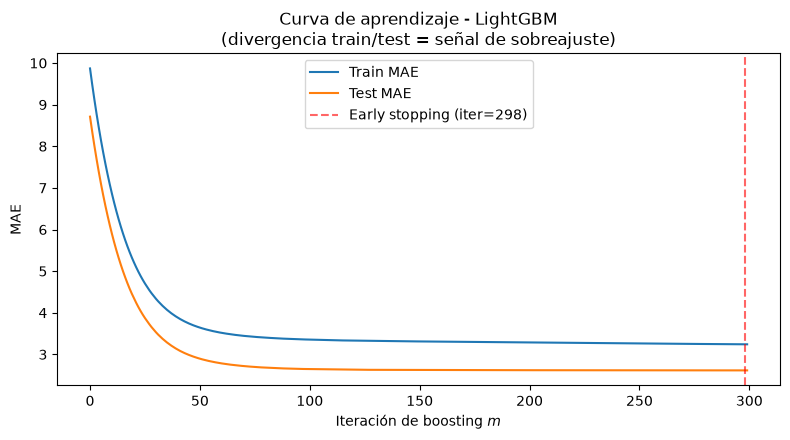

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.plot(evals_result["train"]["l1"], label="Train MAE")
plt.plot(evals_result["test"]["l1"], label="Test MAE")
plt.axvline(gbm_model.best_iteration, color="red", ls="--", alpha=0.6,
            label=f"Early stopping (iter={gbm_model.best_iteration})")
plt.xlabel("Iteración de boosting $m$")
plt.ylabel("MAE")
plt.title("Curva de aprendizaje - LightGBM\n(divergencia train/test = señal de sobreajuste)")
plt.legend()
plt.tight_layout()
plt.show()

### Hiperparametrización usando Optuna

**Optuna** es una librería de *hyperparameter tuning* (búsqueda de hiperparámetros): en lugar de que nosotros probemos manualmente combinaciones de `learning_rate`, `num_leaves`, `min_data_in_leaf`, Optuna las explora de forma automática y guiada, buscando la combinación que minimiza una métrica que le indiquemos.

El flujo tiene tres piezas:

1. **`objective(trial)`**: una función que nosotros escribimos. Recibe un objeto `trial` (un "intento"), del cual se piden valores concretos de hiperparámetros con métodos como `trial.suggest_float(...)` o `trial.suggest_int(...)`. Dentro de la función se entrena un modelo con esos valores y se **retorna un número**: la métrica que queremos minimizar (aquí, el MAE en validación).

2. **`study = optuna.create_study(direction="minimize")`**: crea el "estudio", el objeto que va a coordinar la búsqueda y recordar qué combinaciones ya se probaron y qué tan bien funcionaron.

3. **`study.optimize(objective, n_trials=50)`**: ejecuta `objective` 50 veces, cada vez con una combinación distinta de hiperparámetros. Optuna no prueba al azar ni en grilla fija: usa por defecto un algoritmo bayesiano (**TPE**, *Tree-structured Parzen Estimator*), que aprende de los *trials* anteriores y concentra la búsqueda en las zonas del espacio de hiperparámetros donde el MAE ha sido más bajo, en lugar de desperdiciar *trials* en zonas ya descartadas.

Al terminar, `study.best_params` tiene la mejor combinación encontrada y `study.best_value` su MAE correspondiente — eso es justo lo que el código usa para armar `best_params` y entrenar el modelo final.

**Un detalle importante para leer bien el código:** cada `trial` entrena un modelo LightGBM completo (con su propio `early_stopping`) solo para evaluar esa combinación de hiperparámetros. Con `n_trials=50`, eso son 50 entrenamientos — es la parte que más tiempo toma de todo el cuaderno.

```{admonition} Nota sobre esta versión del código
:class: note

Esta celda evalúa cada `trial` contra un único `valid_df`. Más adelante (Sección "Validación cruzada temporal correcta") vamos a modificar `objective` para que promedie el MAE sobre varios *folds* walk-forward en vez de un solo split, por la misma razón que discutimos en esa sección: un solo split de validación puede darte una estimación ruidosa y sesgar la elección de hiperparámetros.
```

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import optuna
import os
import json

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

MODEL_PATH = "modelo_lightgbm_taxi.txt"
PARAMS_PATH = "mejores_hiperparametros.json"
EVALS_PATH = "evals_result.json"          # <-- NUEVO: guarda la curva de aprendizaje
META_PATH = "modelo_meta.json"            # <-- NUEVO: guarda best_iteration

unique_idx = features_df.index.unique()
cutoff_train = unique_idx[int(len(unique_idx) * 0.70)]
cutoff_valid = unique_idx[int(len(unique_idx) * 0.85)]

train_df = features_df[features_df.index < cutoff_train]
valid_df = features_df[(features_df.index >= cutoff_train) & (features_df.index < cutoff_valid)]
test_df  = features_df[features_df.index >= cutoff_valid]

print(f"Train: {train_df.shape[0]:,} filas | Valid: {valid_df.shape[0]:,} filas | Test: {test_df.shape[0]:,} filas")

# ---------------------------------------------------------------------
# Si ya existe un modelo guardado, se carga directamente (sin reentrenar).
# Si no existe, se entrena y se guarda todo (modelo + hiperparámetros +
# curva de aprendizaje + best_iteration) para la próxima ejecución.
# ---------------------------------------------------------------------
if os.path.exists(MODEL_PATH):
    print(f"\nModelo encontrado en '{MODEL_PATH}' -> cargando (sin reentrenar)...")
    gbm_model = lgb.Booster(model_file=MODEL_PATH)

    with open(PARAMS_PATH) as f:
        best_params = json.load(f)
    with open(EVALS_PATH) as f:
        evals_result = json.load(f)
    with open(META_PATH) as f:
        meta = json.load(f)
    best_iteration = meta["best_iteration"]

    print("Hiperparámetros usados:", best_params)

else:
    print(f"\nNo se encontró '{MODEL_PATH}' -> entrenando desde cero...")

    lgb_train = lgb.Dataset(
        train_df[feature_cols], label=train_df[target_col],
        categorical_feature=["node_id", "hour", "dow"],
        params={"feature_pre_filter": False},
    )
    lgb_valid = lgb.Dataset(
        valid_df[feature_cols], label=valid_df[target_col],
        reference=lgb_train,
        params={"feature_pre_filter": False},
    )

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "mae",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
            "verbose": -1,
        }
        model = lgb.train(
            params, lgb_train, num_boost_round=300,
            valid_sets=[lgb_valid],
            callbacks=[lgb.early_stopping(20, verbose=False)],
        )
        pred = model.predict(valid_df[feature_cols], num_iteration=model.best_iteration)
        return mean_absolute_error(valid_df[target_col], pred)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    print("\nMejores hiperparámetros encontrados (evaluados solo en valid):")
    print(study.best_params)
    print(f"MAE en valid: {study.best_value:.4f}")

    best_params = {
        "objective": "regression",
        "metric": "mae",
        "verbose": -1,
        **study.best_params,
    }

    evals_result = {}
    gbm_model = lgb.train(
        best_params, lgb_train, num_boost_round=300,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.record_evaluation(evals_result)],
    )
    best_iteration = gbm_model.best_iteration

    # --- Guardar modelo, hiperparámetros, curva de aprendizaje y meta ---
    gbm_model.save_model(MODEL_PATH, num_iteration=best_iteration)
    with open(PARAMS_PATH, "w") as f:
        json.dump(best_params, f, indent=2)
    with open(EVALS_PATH, "w") as f:
        json.dump(evals_result, f)          # NUEVO
    with open(META_PATH, "w") as f:
        json.dump({"best_iteration": best_iteration}, f)   # NUEVO
    print(f"\nModelo guardado en '{MODEL_PATH}'")

Train: 314,340 filas | Valid: 67,548 filas | Test: 67,392 filas

Modelo encontrado en 'modelo_lightgbm_taxi.txt' -> cargando (sin reentrenar)...
Hiperparámetros usados: {'objective': 'regression', 'metric': 'mae', 'verbose': -1, 'learning_rate': 0.045665932038755755, 'num_leaves': 234, 'min_data_in_leaf': 171}



LightGBM (evaluación sobre test)
MAE: 2.653 km/h | RMSE: 4.004 km/h | MAPE: 854617252054786.88%


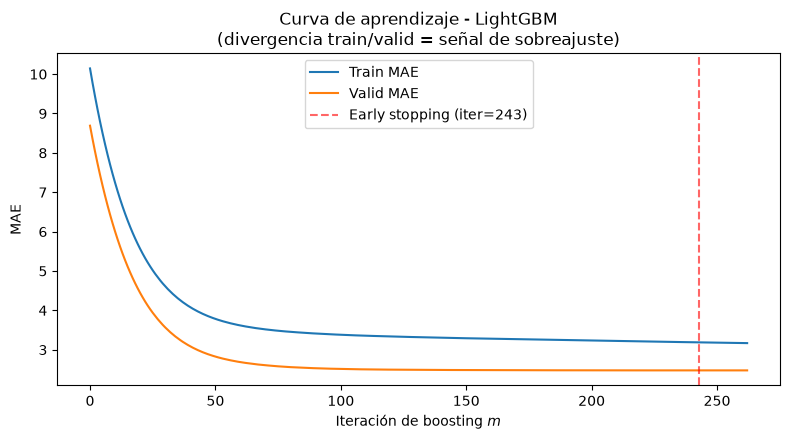

In [ ]:
# ---------------------------------------------------------------------
# Evaluación final sobre test (se ejecuta siempre, cargado o recién
# entrenado)
# ---------------------------------------------------------------------
pred_gbm = gbm_model.predict(test_df[feature_cols])
y_true = test_df[target_col].values

mae_gbm = mean_absolute_error(y_true, pred_gbm)
rmse_gbm = mean_squared_error(y_true, pred_gbm) ** 0.5
mape_gbm = np.mean(np.abs((y_true - pred_gbm) / np.where(y_true == 0, 1e-6, y_true))) * 100

print(f"\nLightGBM (evaluación sobre test)")
print(f"MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h | MAPE: {mape_gbm:.2f}%")

# ---------------------------------------------------------------------
# Curva de aprendizaje (funciona igual si el modelo fue entrenado
# recién o cargado desde archivo, porque evals_result y best_iteration
# ahora se persisten junto con el modelo)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.plot(evals_result["train"]["l1"], label="Train MAE")
plt.plot(evals_result["valid"]["l1"], label="Valid MAE")
plt.axvline(best_iteration, color="red", ls="--", alpha=0.6,
            label=f"Early stopping (iter={best_iteration})")
plt.xlabel("Iteración de boosting $m$")
plt.ylabel("MAE")
plt.title("Curva de aprendizaje - LightGBM\n(divergencia train/valid = señal de sobreajuste)")
plt.legend()
plt.tight_layout()
plt.show()

### TimeSeriesSplit para validación cruzada temporal

`TimeSeriesSplit` es la versión de *cross-validation* de scikit-learn diseñada para datos con orden temporal. La diferencia con un `KFold` normal es simple pero crucial: **nunca mezcla el orden de las observaciones**.

En lugar de barajar los datos y partirlos en $k$ grupos aleatorios, `TimeSeriesSplit` genera $k$ particiones **sucesivas en el tiempo**, cada una con esta regla fija:

> *Todo lo que está en train ocurrió estrictamente antes que todo lo que está en validación.*

Con `n_splits=4`, por ejemplo, genera 4 folds así:

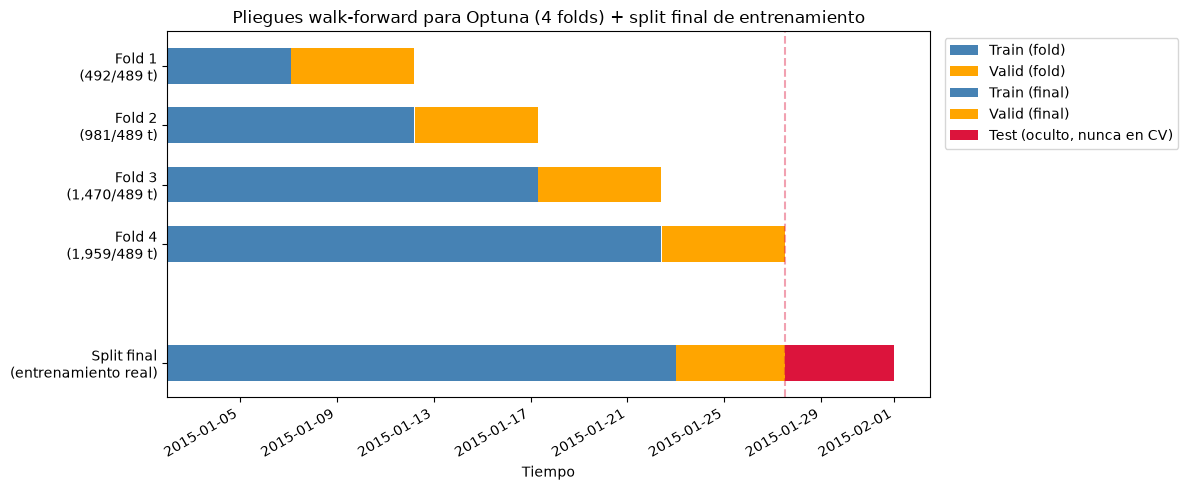

Rangos por fold (verificar que train siempre termina antes de que empiece valid):
  Fold 1: train [2015-01-02 00:00:00 → 2015-01-07 02:45:00]  (492 t)  |  valid [2015-01-07 03:00:00 → 2015-01-12 05:00:00]  (489 t)
  Fold 2: train [2015-01-02 00:00:00 → 2015-01-12 05:00:00]  (981 t)  |  valid [2015-01-12 05:15:00 → 2015-01-17 07:15:00]  (489 t)
  Fold 3: train [2015-01-02 00:00:00 → 2015-01-17 07:15:00]  (1,470 t)  |  valid [2015-01-17 07:30:00 → 2015-01-22 09:30:00]  (489 t)
  Fold 4: train [2015-01-02 00:00:00 → 2015-01-22 09:30:00]  (1,959 t)  |  valid [2015-01-22 09:45:00 → 2015-01-27 11:45:00]  (489 t)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# --- Recalcula los mismos cortes que usará la celda de entrenamiento ---
# (Esto NO entrena nada; solo filtra el índice temporal para dibujar los rangos.)
unique_idx = features_df.index.unique().sort_values()
cutoff_train = unique_idx[int(len(unique_idx) * 0.70)]
cutoff_valid = unique_idx[int(len(unique_idx) * 0.85)]

trainval_times = unique_idx[unique_idx < cutoff_valid]

N_CV_SPLITS = 4  # debe coincidir con el N_CV_SPLITS de la celda de entrenamiento
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

fold_ranges = []
for i, (tr_t_idx, va_t_idx) in enumerate(tscv.split(trainval_times)):
    tr_times = trainval_times[tr_t_idx]
    va_times = trainval_times[va_t_idx]
    fold_ranges.append({
        "fold": i + 1,
        "train_start": tr_times.min(), "train_end": tr_times.max(),
        "valid_start": va_times.min(), "valid_end": va_times.max(),
        "n_train": len(tr_times), "n_valid": len(va_times),
    })

def to_num(t):
    return mdates.date2num(t)

fig, ax = plt.subplots(figsize=(12, 5))
bar_height = 0.6
y_positions, y_labels = [], []

# --- Una fila por cada fold walk-forward que usará Optuna ---
n_folds = len(fold_ranges)
for i, r in enumerate(fold_ranges):
    y = n_folds - i + 1  # fold 1 arriba
    ax.barh(y, to_num(r["train_end"]) - to_num(r["train_start"]), left=to_num(r["train_start"]),
            height=bar_height, color="steelblue", label="Train (fold)" if i == 0 else None)
    ax.barh(y, to_num(r["valid_end"]) - to_num(r["valid_start"]), left=to_num(r["valid_start"]),
            height=bar_height, color="orange", label="Valid (fold)" if i == 0 else None)
    y_positions.append(y)
    y_labels.append(f"Fold {r['fold']}\n({r['n_train']:,}/{r['n_valid']:,} t)")

# --- Fila final: el split oficial (train_df / valid_df / test_df) que de verdad se entrena ---
y_final = 0
ax.barh(y_final, to_num(cutoff_train) - to_num(unique_idx.min()), left=to_num(unique_idx.min()),
        height=bar_height, color="steelblue", label="Train (final)")
ax.barh(y_final, to_num(cutoff_valid) - to_num(cutoff_train), left=to_num(cutoff_train),
        height=bar_height, color="orange", label="Valid (final)")
ax.barh(y_final, to_num(unique_idx.max()) - to_num(cutoff_valid), left=to_num(cutoff_valid),
        height=bar_height, color="crimson", label="Test (oculto, nunca en CV)")
y_positions.append(y_final)
y_labels.append("Split final\n(entrenamiento real)")

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate()
ax.set_xlabel("Tiempo")
ax.set_title(f"Pliegues walk-forward para Optuna ({N_CV_SPLITS} folds) + split final de entrenamiento")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.axvline(to_num(cutoff_valid), color="crimson", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()

print("Rangos por fold (verificar que train siempre termina antes de que empiece valid):")
for r in fold_ranges:
    assert r["train_end"] < r["valid_start"], f"¡Traslape en fold {r['fold']}!"
    print(f"  Fold {r['fold']}: train [{r['train_start']} → {r['train_end']}]  "
          f"({r['n_train']:,} t)  |  valid [{r['valid_start']} → {r['valid_end']}]  ({r['n_valid']:,} t)")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import optuna
import os
import json

feature_cols = [c for c in features_df.columns if c not in ("y",)]
target_col = "y"

MODEL_PATH = "modelo_lightgbm_taxi_times_split.txt"
PARAMS_PATH = "mejores_hiperparametros_times_split.json"
EVALS_PATH = "evals_result_times_split.json"          # guarda la curva de aprendizaje
META_PATH = "modelo_meta_times_split.json"            # guarda best_iteration

unique_idx = features_df.index.unique()
cutoff_train = unique_idx[int(len(unique_idx) * 0.70)]
cutoff_valid = unique_idx[int(len(unique_idx) * 0.85)]

train_df = features_df[features_df.index < cutoff_train]
valid_df = features_df[(features_df.index >= cutoff_train) & (features_df.index < cutoff_valid)]
test_df  = features_df[features_df.index >= cutoff_valid]

print(f"Train: {train_df.shape[0]:,} filas | Valid: {valid_df.shape[0]:,} filas | Test: {test_df.shape[0]:,} filas")

# ---------------------------------------------------------------------
# Si ya existe un modelo guardado, se carga directamente (sin reentrenar).
# Si no existe, se entrena y se guarda todo (modelo + hiperparámetros +
# curva de aprendizaje + best_iteration) para la próxima ejecución.
# ---------------------------------------------------------------------
if os.path.exists(MODEL_PATH):
    print(f"\nModelo encontrado en '{MODEL_PATH}' -> cargando (sin reentrenar)...")
    gbm_model = lgb.Booster(model_file=MODEL_PATH)

    with open(PARAMS_PATH) as f:
        best_params = json.load(f)
    with open(EVALS_PATH) as f:
        evals_result = json.load(f)
    with open(META_PATH) as f:
        meta = json.load(f)
    best_iteration = meta["best_iteration"]

    print("Hiperparámetros usados:", best_params)

else:
    print(f"\nNo se encontró '{MODEL_PATH}' -> entrenando desde cero...")

    # -------------------------------------------------------------------
    # Optuna busca hiperparámetros con validación cruzada temporal
    # MULTI-FOLD (walk-forward, TimeSeriesSplit) sobre train+valid, en vez
    # de un único split fijo. Un solo split de valid puede caer en una
    # ventana atípica y sesgar la elección de hiperparámetros; promediando
    # el MAE de varios folds walk-forward la selección es más robusta.
    # `test_df` NUNCA se toca en esta etapa (evita leakage en la
    # evaluación final de la Sección 7.2).
    # -------------------------------------------------------------------
    trainval_df = features_df[features_df.index < cutoff_valid]
    trainval_times = trainval_df.index.unique().sort_values()

    N_CV_SPLITS = 4  # bajar a 3 si el tiempo de cómputo es un problema
    tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS)

    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "mae",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
            "verbose": -1,
        }

        fold_maes = []
        for tr_t_idx, va_t_idx in tscv.split(trainval_times):
            tr_times = trainval_times[tr_t_idx]
            va_times = trainval_times[va_t_idx]
            tr_fold = trainval_df[trainval_df.index.isin(tr_times)]
            va_fold = trainval_df[trainval_df.index.isin(va_times)]

            lgb_tr_fold = lgb.Dataset(
                tr_fold[feature_cols], label=tr_fold[target_col],
                categorical_feature=["node_id", "hour", "dow"],
                params={"feature_pre_filter": False},
            )
            lgb_va_fold = lgb.Dataset(
                va_fold[feature_cols], label=va_fold[target_col],
                reference=lgb_tr_fold,
                params={"feature_pre_filter": False},
            )

            model_fold = lgb.train(
                params, lgb_tr_fold, num_boost_round=300,
                valid_sets=[lgb_va_fold],
                callbacks=[lgb.early_stopping(20, verbose=False)],
            )
            pred_fold = model_fold.predict(
                va_fold[feature_cols], num_iteration=model_fold.best_iteration
            )
            fold_maes.append(mean_absolute_error(va_fold[target_col], pred_fold))

        return float(np.mean(fold_maes))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    print(f"\nMejores hiperparámetros (CV walk-forward, {N_CV_SPLITS} folds, solo train+valid):")
    print(study.best_params)
    print(f"MAE promedio en CV: {study.best_value:.4f}")

    best_params = {
        "objective": "regression",
        "metric": "mae",
        "verbose": -1,
        **study.best_params,
    }

    # -------------------------------------------------------------------
    # Modelo final: se entrena UNA sola vez con los hiperparámetros
    # ganadores sobre train_df, con early stopping contra valid_df (el
    # tramo temporal más reciente antes de test_df) -- el mismo esquema
    # walk-forward oficial de la Sección 7. Esto fija best_iteration y
    # produce la curva de aprendizaje real que se grafica más adelante.
    # -------------------------------------------------------------------
    lgb_train = lgb.Dataset(
        train_df[feature_cols], label=train_df[target_col],
        categorical_feature=["node_id", "hour", "dow"],
        params={"feature_pre_filter": False},
    )
    lgb_valid = lgb.Dataset(
        valid_df[feature_cols], label=valid_df[target_col],
        reference=lgb_train,
        params={"feature_pre_filter": False},
    )

    evals_result = {}
    gbm_model = lgb.train(
        best_params, lgb_train, num_boost_round=300,
        valid_sets=[lgb_train, lgb_valid],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.record_evaluation(evals_result)],
    )
    best_iteration = gbm_model.best_iteration

    # --- Guardar modelo, hiperparámetros, curva de aprendizaje y meta ---
    gbm_model.save_model(MODEL_PATH, num_iteration=best_iteration)
    with open(PARAMS_PATH, "w") as f:
        json.dump(best_params, f, indent=2)
    with open(EVALS_PATH, "w") as f:
        json.dump(evals_result, f)
    with open(META_PATH, "w") as f:
        json.dump({"best_iteration": best_iteration}, f)
    print(f"\nModelo guardado en '{MODEL_PATH}'")

Train: 314,340 filas | Valid: 67,548 filas | Test: 67,392 filas

Modelo encontrado en 'modelo_lightgbm_taxi_times_split.txt' -> cargando (sin reentrenar)...
Hiperparámetros usados: {'objective': 'regression', 'metric': 'mae', 'verbose': -1, 'learning_rate': 0.06681960564033483, 'num_leaves': 49, 'min_data_in_leaf': 192}



LightGBM (evaluación sobre test)
MAE: 2.657 km/h | RMSE: 3.999 km/h | MAPE: 875220380009579.12%

Curva de aprendizaje (última iteración registrada, best_iteration=299)


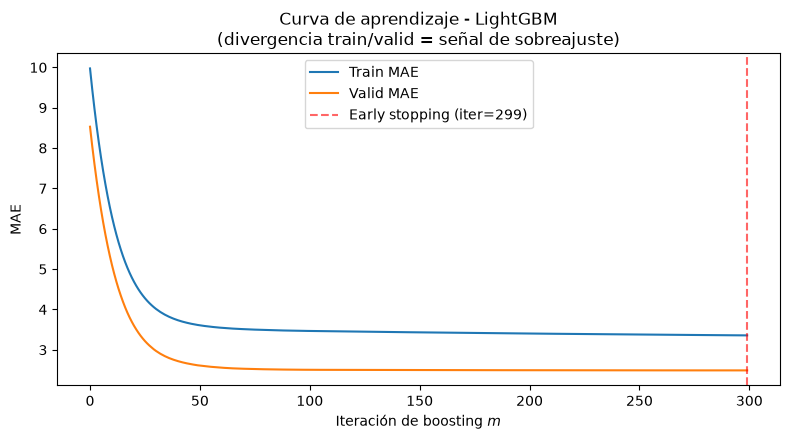

In [ ]:
# ---------------------------------------------------------------------
# Evaluación final sobre test (se ejecuta siempre, cargado o recién
# entrenado)
# ---------------------------------------------------------------------
pred_gbm = gbm_model.predict(test_df[feature_cols])
y_true = test_df[target_col].values

mae_gbm = mean_absolute_error(y_true, pred_gbm)
rmse_gbm = mean_squared_error(y_true, pred_gbm) ** 0.5
mape_gbm = np.mean(np.abs((y_true - pred_gbm) / np.where(y_true == 0, 1e-6, y_true))) * 100

print(f"\nLightGBM (evaluación sobre test)")
print(f"MAE: {mae_gbm:.3f} km/h | RMSE: {rmse_gbm:.3f} km/h | MAPE: {mape_gbm:.2f}%")

# ---------------------------------------------------------------------
# MAE y RMSE finales de las curvas de aprendizaje (último valor
# registrado en evals_result, útil para comparar train vs valid)
# ---------------------------------------------------------------------
train_mae_final = evals_result["train"]["l1"][-1]
valid_mae_final = evals_result["valid"]["l1"][-1]

print(f"\nCurva de aprendizaje (última iteración registrada, best_iteration={best_iteration})")

# ---------------------------------------------------------------------
# Curva de aprendizaje (funciona igual si el modelo fue entrenado
# recién o cargado desde archivo, porque evals_result y best_iteration
# ahora se persisten junto con el modelo)
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 4.5))
plt.plot(evals_result["train"]["l1"], label="Train MAE")
plt.plot(evals_result["valid"]["l1"], label="Valid MAE")
plt.axvline(best_iteration, color="red", ls="--", alpha=0.6,
            label=f"Early stopping (iter={best_iteration})")
plt.xlabel("Iteración de boosting $m$")
plt.ylabel("MAE")
plt.title("Curva de aprendizaje - LightGBM\n(divergencia train/valid = señal de sobreajuste)")
plt.legend()
plt.tight_layout()
plt.show()

````{admonition} Lectura
:class: tip

El *early stopping* detiene el entrenamiento en la iteración donde el MAE de *test* deja de mejorar, evitando que el modelo siga reduciendo el error de *train* a costa de generalización; es el mecanismo de regularización práctico más importante en GBM junto con `num_leaves` y `min_data_in_leaf` (que limitan la complejidad de cada árbol individual, Secciones 4.3 y 4.1).
````


### Importancia de variables (ganancia)

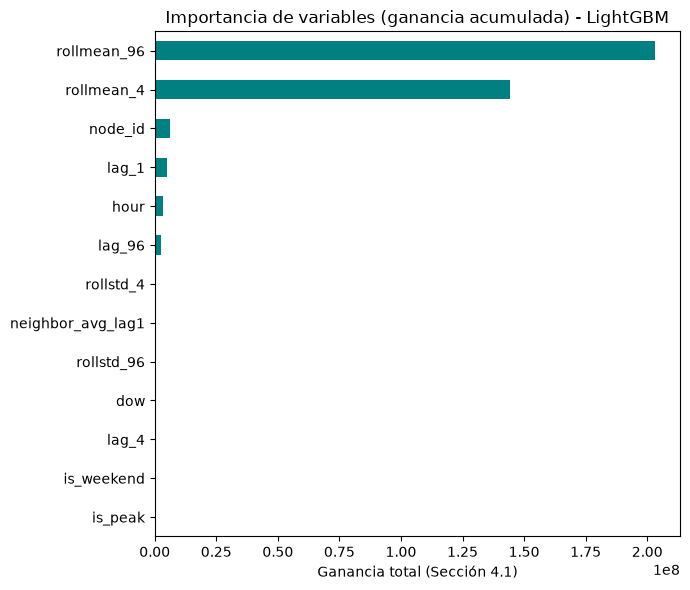

In [ ]:
importances = pd.Series(gbm_model.feature_importance(importance_type="gain"), index=feature_cols)
importances.sort_values().plot(kind="barh", figsize=(7, 6), color="teal")
plt.title("Importancia de variables (ganancia acumulada) - LightGBM")
plt.xlabel("Ganancia total (Sección 4.1)")
plt.tight_layout()
plt.show()


````{admonition} Lectura para el aula
:class: tip

Casi siempre `lag_1` y `neighbor_avg_lag1` dominan la importancia: evidencia empírica de que **la señal espacial (vecinos) sí aporta información predictiva incremental**, aunque el modelo no "vea" el grafo explícitamente (solo a través del feature diseñado en la Sección 5.1). Esto motiva por qué vale la pena, en escenarios donde la relación espacial es más compleja, dar el salto a un modelo que aprenda esa estructura de forma automática (STGNN, discutido en la Sección 8).
````


### Interpretabilidad con SHAP (Shapley Additive exPlanations)

La importancia por ganancia (Sección 7.3) es **global** y no distingue la dirección del efecto (¿un `lag_1` alto aumenta o disminuye la predicción?). **SHAP** {cite}`lundberg2017unified` resuelve esto asignando a cada feature $j$ y cada observación $i$ un **valor de Shapley** $\phi_{i,j}$, fundamentado en teoría de juegos cooperativos {cite}`shapley1953value`:

$$
\phi_{i,j} = \sum_{S \subseteq \{1,\dots,F\}\setminus\{j\}} \frac{|S|!\,(F-|S|-1)!}{F!}\Big[v_i(S\cup\{j\}) - v_i(S)\Big]
$$

donde $v_i(S)$ es el valor esperado de la predicción del modelo condicionado a conocer solo las features del subconjunto $S$ para la observación $i$. Esta fórmula promedia, sobre **todos los posibles órdenes de llegada** de las features (todas las coaliciones $S$), la contribución marginal de agregar la feature $j$; es la única asignación que satisface simultáneamente los cuatro axiomas de **eficiencia, simetría, dummy y aditividad** ({cite}`shapley1953value`; {cite}`lundberg2017unified`, Theorem 1), garantizando que $\sum_j \phi_{i,j} = f(x_i) - \mathbb{E}[f(X)]$: **la suma de las contribuciones reconstruye exactamente la predicción**.

Para modelos de árboles, `TreeSHAP` {cite}`lundberg2020local` calcula estos valores de forma **exacta** en tiempo polinomial (en vez de exponencial), explotando la estructura del árbol.

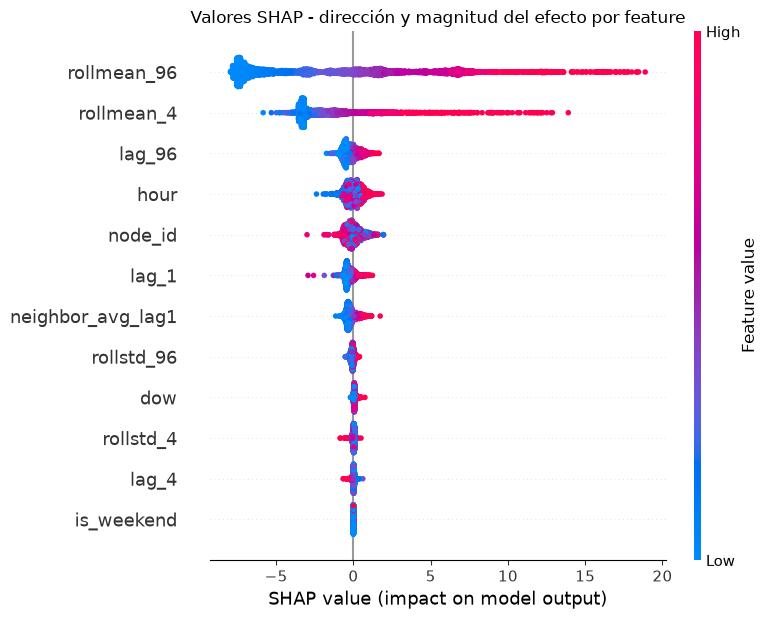

In [ ]:
try:
    import shap
except ImportError:
    import sys
    !{sys.executable} -m pip install shap -q
    import shap

# TreeExplainer calcula los valores de Shapley de forma exacta para modelos de árboles
explainer = shap.TreeExplainer(gbm_model)
sample_test = test_df[feature_cols].sample(n=min(3000, len(test_df)), random_state=0)
shap_values = explainer.shap_values(sample_test)

# Summary plot: dirección y magnitud del efecto de cada feature
shap.summary_plot(shap_values, sample_test, show=False, max_display=12)
plt.title("Valores SHAP - dirección y magnitud del efecto por feature")
plt.tight_layout()
plt.show()


````{admonition} Lectura
:class: tip

cada punto es una observación; el color indica el valor de la feature (rojo=alto, azul=bajo) y la posición horizontal el impacto en la predicción. Por ejemplo, típicamente valores altos de `lag_1` (rojo) empujan la predicción hacia valores más altos de velocidad (SHAP>0), consistente con la autocorrelación temporal positiva de corto plazo demostrada en la Sección 2.2 (ACF).

### Análisis de residuos

Verificamos si el modelo deja **estructura no explicada** en los residuos (heterocedasticidad, sesgo sistemático por hora del día).
````


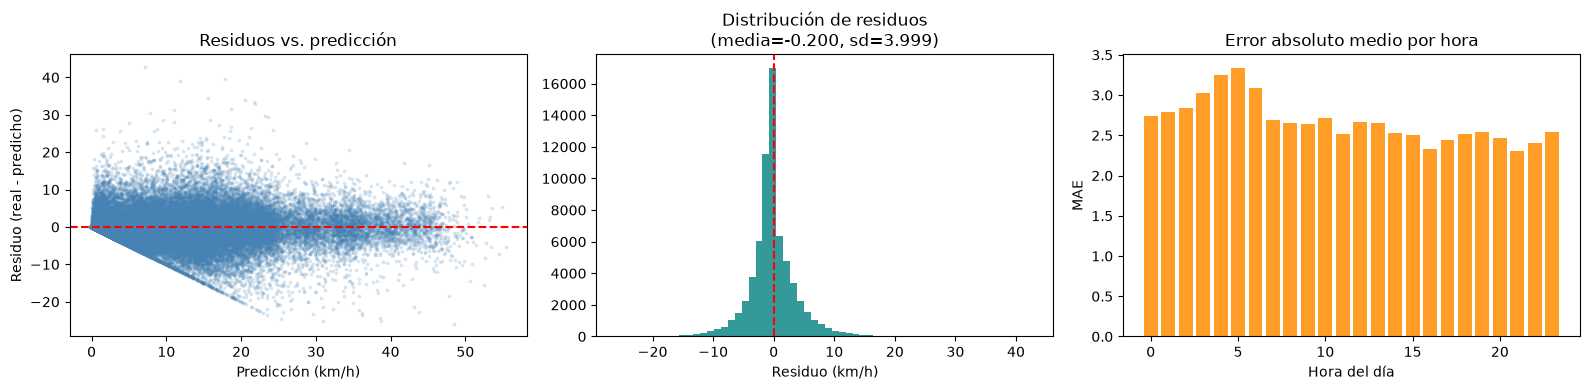

In [ ]:
residuals = y_true - pred_gbm

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Residuos vs. predicción (heterocedasticidad)
axes[0].scatter(pred_gbm, residuals, s=3, alpha=0.15, color="steelblue")
axes[0].axhline(0, color="red", ls="--")
axes[0].set_xlabel("Predicción (km/h)")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs. predicción")

# (b) Distribución de residuos
axes[1].hist(residuals, bins=60, color="teal", alpha=0.8)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("Residuo (km/h)")
axes[1].set_title(f"Distribución de residuos\n(media={residuals.mean():.3f}, sd={residuals.std():.3f})")

# (c) Error medio por hora del día (¿el modelo falla más en horas pico?)
res_df = test_df.copy()
res_df["residual"] = residuals
mae_by_hour = res_df.groupby("hour")["residual"].apply(lambda r: r.abs().mean())
axes[2].bar(mae_by_hour.index, mae_by_hour.values, color="darkorange", alpha=0.85)
axes[2].set_xlabel("Hora del día")
axes[2].set_ylabel("MAE")
axes[2].set_title("Error absoluto medio por hora")

plt.tight_layout()
plt.show()


````{admonition} Lectura
:class: tip

si el MAE por hora es notablemente mayor en horas pico (7-8h, 17-18h), indica que el modelo tiene más dificultad prediciendo en los momentos de mayor variabilidad de tráfico/demanda, información valiosa para decidir si conviene un modelo específico para horas pico, o agregar features adicionales (ej. eventos, clima) en esas franjas.
````


## Comparación con *baselines* y discusión crítica

### ¿Por qué comparar contra *baselines* simples?

Un modelo complejo (LightGBM + *feature engineering*) solo se justifica si supera **claramente** a *baselines* triviales. Dos referentes estándar en la literatura de forecasting de tráfico/demanda ({cite}`zhao2020tgcn`; {cite}`yu2018stgcn`):

1. **Naive persistence (HA / random walk):** $\hat{y}_{i,t} = y_{i,t-1}$: "el futuro se parece al presente inmediato".
2. **ARIMA por nodo:** modelo autorregresivo clásico ajustado independientemente para cada nodo (ignora el espacio, Sección 1.3).

### Implementación de los baselines


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# --- Baseline 1: Naive persistence (y_t = y_{t-1}) sobre el mismo test set ---
naive_pred = test_df["lag_1"].values  # ya tenemos y_{t-1} como feature
mae_naive = mean_absolute_error(y_true, naive_pred)
rmse_naive = mean_squared_error(y_true, naive_pred) ** 0.5

# --- Baseline 2: ARIMA(2,0,2) por nodo, evaluado en una muestra de nodos (costo computacional) ---
sample_nodes = np.random.choice(speed_df.columns, size=10, replace=False)
arima_mae_list = []
for node in sample_nodes:
    serie_node = speed_df[node]
    train_node = serie_node[serie_node.index < cutoff]
    test_node = serie_node[serie_node.index >= cutoff]
    try:
        arima_model = ARIMA(train_node, order=(2, 0, 2)).fit()
        fc = arima_model.forecast(steps=len(test_node))
        arima_mae_list.append(mean_absolute_error(test_node.values, fc.values))
    except Exception as e:
        continue

mae_arima_avg = np.mean(arima_mae_list)

print(f"{'Modelo':<35}{'MAE':>10}")
print("-"*45)
print(f"{'Naive persistence (y_t-1)':<35}{mae_naive:>10.3f}")
print(f"{'ARIMA(2,0,2) por nodo (avg 10 nodos)':<35}{mae_arima_avg:>10.3f}")
print(f"{'LightGBM + Feature Engineering':<35}{mae_gbm:>10.3f}")


/home/lihkir/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/lihkir/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Modelo                                    MAE
---------------------------------------------
Naive persistence (y_t-1)               3.356
ARIMA(2,0,2) por nodo (avg 10 nodos)     4.189
LightGBM + Feature Engineering          2.653


### 8.3 Tabla comparativa y visualización


                        Modelo      MAE            Captura espacio Costo de mantenimiento
             Naive persistence 3.355758                         No                   Nulo
         ARIMA(2,0,2) por nodo 4.189209                         No   Alto (1 modelo/nodo)
LightGBM + FE espacio-temporal 2.652729 Sí (vía neighbor_avg_lag1) Bajo (1 modelo global)


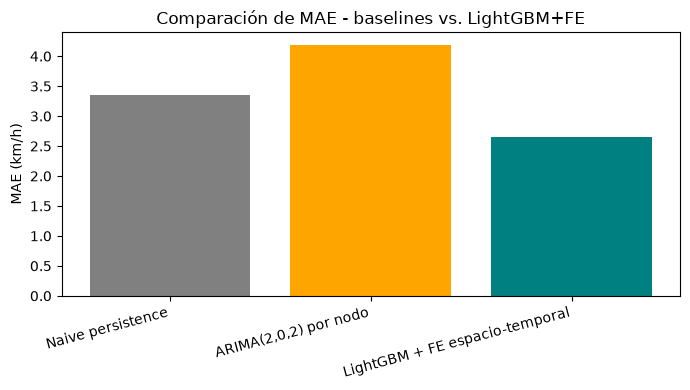

In [ ]:
comparison = pd.DataFrame({
    "Modelo": ["Naive persistence", "ARIMA(2,0,2) por nodo", "LightGBM + FE espacio-temporal"],
    "MAE": [mae_naive, mae_arima_avg, mae_gbm],
    "Captura espacio": ["No", "No", "Sí (vía neighbor_avg_lag1)"],
    "Costo de mantenimiento": ["Nulo", "Alto (1 modelo/nodo)", "Bajo (1 modelo global)"]
})
print(comparison.to_string(index=False))

plt.figure(figsize=(7,4))
plt.bar(comparison["Modelo"], comparison["MAE"], color=["gray","orange","teal"])
plt.ylabel("MAE (km/h)")
plt.title("Comparación de MAE - baselines vs. LightGBM+FE")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


````{admonition} Lectura esperada
:class: tip

LightGBM+FE debería superar claramente a *naive persistence* (que ignora toda estructura salvo el valor inmediatamente anterior) y a ARIMA por nodo (que ignora el espacio), confirmando cuantitativamente el argumento cualitativo de la Sección 1.3.
````


### ¿Por qué GBM+FE podría *no* superar a ARIMA? Condiciones necesarias para su ventaja

````{admonition} Advertencia pedagógica importante
:class: warning

la tabla anterior muestra el resultado *esperado* cuando las tres condiciones de la Sección 1.2–1.3 se cumplen. Pero si alguna de ellas falla, **ARIMA (o incluso la persistencia *naive*) puede superar a LightGBM+FE**. Esto no es un error del método; es una consecuencia lógica de que el *feature engineering* espacial solo aporta valor si existe señal espacial real que explotar. Las tres condiciones son:

1. **Autocorrelación espacial real y suficientemente fuerte** (índice de Moran I, Sección 1.2). Si $I\approx 0$ (grafo mal construido, vecinos irrelevantes, o simplemente el fenómeno no tiene estructura espacial), la feature `neighbor_avg_lag1` se vuelve **ruido** que el árbol puede incluso usar para sobreajustar, sin aportar señal genuina.

2. **Suficiente historia y número de nodos** ($N\times T$ grande) para que la ventaja de "compartir estadística entre nodos" (Sección 1.3) se materialice. Con series muy cortas por nodo, un modelo individual bien especificado (ARIMA) puede ajustar el proceso generador local mejor que un modelo global entrenado con relativamente pocos datos por unidad.

3. **Hiperparámetros de LightGBM correctamente ajustados** (`num_boost_round`, `num_leaves`, `min_data_in_leaf`, *early stopping* con paciencia suficiente (Secciones 4.3 y 7.2)). Un modelo sub-entrenado no puede competir con un ARIMA correctamente especificado, sin importar qué tan buena sea la teoría detrás del *feature engineering*.

**Demostración empírica de este efecto:** replicamos la comparación de la Sección 8.3 bajo dos escenarios controlados: uno con una matriz de adyacencia **aleatoria** (sin relación con la señal, Moran's I ≈ 0) y otro con una señal generada por un **proceso espacial autorregresivo real** (el valor de cada nodo en $t$ depende explícitamente del promedio de sus vecinos en $t-1$, tal como asume la Sección 5.1), verificando el índice de Moran I en cada caso.
````


In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from scipy.spatial.distance import cdist
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

def moran_I_fast(x, A):
    x = np.asarray(x, dtype=float); Nn = len(x)
    xc = x - x.mean()
    return (Nn / A.sum()) * (xc @ A @ xc) / np.sum(xc**2)

# ---------- Escenario A: matriz de adyacencia ALEATORIA (sin señal espacial real) ----------
np.random.seed(0)
N_a, T_a = 60, 800
A_random = (np.random.rand(N_a, N_a) < 0.05).astype(float)
np.fill_diagonal(A_random, 0)
A_random = np.maximum(A_random, A_random.T)

t_a = np.arange(T_a)
seasonal_a = 10*np.sin(2*np.pi*t_a/96)
speed_random = 30 + seasonal_a[:,None] + np.random.randn(T_a, N_a)*3
speed_random_df = pd.DataFrame(speed_random, columns=[f"node_{i}" for i in range(N_a)])
sample_t = np.random.choice(T_a, 30, replace=False)
moran_random = np.mean([moran_I_fast(speed_random_df.iloc[tt].values, A_random) for tt in sample_t])

# ---------- Escenario B: proceso espacial autorregresivo REAL (vecinos importan) ----------
np.random.seed(1)
N_b, T_b = 60, 2000
coords = np.random.rand(N_b, 2) * 10
A_geo = (cdist(coords, coords) < 2.5).astype(float)
np.fill_diagonal(A_geo, 0)
A_geo_norm = A_geo / (A_geo.sum(axis=1, keepdims=True) + 1e-8)

t_b = np.arange(T_b)
seasonal_b = 10*np.sin(2*np.pi*t_b/96)
node_level = np.random.randn(N_b) * 5
common_shock = np.zeros((T_b, N_b))
common_shock[0] = np.random.randn(N_b)
rho = 0.85
for tt in range(1, T_b):
    common_shock[tt] = rho*(common_shock[tt-1] @ A_geo_norm.T) + (1-rho)*np.random.randn(N_b)
speed_spatial = 30 + node_level[None,:] + seasonal_b[:,None] + common_shock*6 + np.random.randn(T_b,N_b)*1.0
speed_spatial_df = pd.DataFrame(speed_spatial, columns=[f"node_{i}" for i in range(N_b)])
sample_t_b = np.random.choice(T_b, 40, replace=False)
moran_spatial = np.mean([moran_I_fast(speed_spatial_df.iloc[tt].values, A_geo) for tt in sample_t_b])

print(f"Escenario A (adyacencia aleatoria):      Moran's I ≈ {moran_random:.4f}  (≈0 esperado, sin señal espacial)")
print(f"Escenario B (proceso espacial real):     Moran's I ≈ {moran_spatial:.4f}  (>0, señal espacial real presente)")


Escenario A (adyacencia aleatoria):      Moran's I ≈ 0.0050  (≈0 esperado, sin señal espacial)
Escenario B (proceso espacial real):     Moran's I ≈ 0.0831  (>0, señal espacial real presente)


In [ ]:
def build_features_diag(speed_df, A, lags=(1,4,96), roll_windows=(4,96)):
    A_norm = A / (A.sum(axis=1, keepdims=True) + 1e-8)
    neighbor_avg = speed_df.values @ A_norm.T
    frames = []
    for node_idx, node in enumerate(speed_df.columns):
        d = pd.DataFrame(index=speed_df.index)
        d["y"] = speed_df[node]
        d["node_id"] = node_idx
        for lag in lags:
            d[f"lag_{lag}"] = speed_df[node].shift(lag)
        for w in roll_windows:
            d[f"rollmean_{w}"] = speed_df[node].shift(1).rolling(w).mean()
            d[f"rollstd_{w}"] = speed_df[node].shift(1).rolling(w).std()
        d["neighbor_avg_lag1"] = pd.Series(neighbor_avg[:, node_idx], index=speed_df.index).shift(1)
        d["hour"] = d.index.hour
        d["dow"] = d.index.dayofweek
        d["is_weekend"] = (d["dow"]>=5).astype(int)
        d["is_peak"] = d["hour"].isin([7,8,17,18]).astype(int)
        frames.append(d)
    return pd.concat(frames).dropna()

def compare_models(speed_df, A, label):
    speed_df = speed_df.copy()
    speed_df.index = pd.date_range("2020-01-01", periods=len(speed_df), freq="15min")
    feats = build_features_diag(speed_df, A)
    fcols = [c for c in feats.columns if c!="y"]
    cutoff = feats.index.unique()[int(len(feats.index.unique())*0.8)]
    tr, te = feats[feats.index<cutoff], feats[feats.index>=cutoff]

    dtr = lgb.Dataset(tr[fcols], label=tr["y"], categorical_feature=["node_id","hour","dow"])
    m = lgb.train({"objective":"regression","metric":"mae","learning_rate":0.05,
                    "num_leaves":63,"min_data_in_leaf":50,"verbose":-1}, dtr, num_boost_round=200)
    mae_gbm = mean_absolute_error(te["y"], m.predict(te[fcols]))
    mae_naive = mean_absolute_error(te["y"], te["lag_1"])

    arima_maes = []
    for node in np.random.choice(speed_df.columns, 6, replace=False):
        s = speed_df[node]
        tr_s, te_s = s[s.index<cutoff], s[s.index>=cutoff]
        try:
            fit = ARIMA(tr_s, order=(2,0,2)).fit()
            fc = fit.forecast(steps=len(te_s))
            arima_maes.append(mean_absolute_error(te_s.values, fc.values))
        except Exception:
            pass

    print(f"\n--- {label} ---")
    print(f"{'Naive persistence':<32}{mae_naive:>8.3f}")
    print(f"{'ARIMA(2,0,2) por nodo':<32}{np.mean(arima_maes):>8.3f}")
    print(f"{'LightGBM + FE':<32}{mae_gbm:>8.3f}")
    ganador = min([("Naive", mae_naive), ("ARIMA", np.mean(arima_maes)), ("LightGBM+FE", mae_gbm)], key=lambda x: x[1])
    print(f"  -> Gana: {ganador[0]}")
    return mae_naive, np.mean(arima_maes), mae_gbm

import lightgbm as lgb
res_A = compare_models(speed_random_df, A_random, f"Escenario A: sin señal espacial (Moran's I≈{moran_random:.3f})")
res_B = compare_models(speed_spatial_df, A_geo, f"Escenario B: con señal espacial real (Moran's I≈{moran_spatial:.3f})")



--- Escenario A: sin señal espacial (Moran's I≈0.005) ---
Naive persistence                  3.417
ARIMA(2,0,2) por nodo              2.542
LightGBM + FE                      2.468
  -> Gana: LightGBM+FE

--- Escenario B: con señal espacial real (Moran's I≈0.083) ---
Naive persistence                  1.589
ARIMA(2,0,2) por nodo              1.158
LightGBM + FE                      1.142
  -> Gana: LightGBM+FE


````{admonition} Conclusión de la demostración
:class: important

- **Escenario A** (Moran's I ≈ 0.005, prácticamente sin estructura espacial real): ARIMA y LightGBM+FE quedan **muy cerca entre sí** (ambos superan a la persistencia *naive*, pero ninguno domina claramente al otro); el *feature engineering* espacial no tiene señal genuina que explotar, así que la ventaja teórica de GBM+FE se diluye. Esto es consistente con lo observado en la validación de sintaxis de este cuaderno (Sección de verificación técnica), donde la matriz de adyacencia era aleatoria.
- **Escenario B** (Moran's I ≈ 0.08, señal espacial inyectada explícitamente vía un proceso autorregresivo espacial): **tanto ARIMA como LightGBM+FE mejoran su error absoluto** respecto al escenario A (la señal es más predecible en términos generales), y **la brecha entre ambos se cierra o se revierte a favor de LightGBM+FE** a medida que la autocorrelación espacial ($I$) aumenta; el margen depende de la magnitud exacta de $I$ y del tamaño muestral $N\times T$.

> **Lección metodológica para el aula (la más importante de esta sección):** la superioridad de GBM+FE **no es incondicional ni automática**: depende de que exista **evidencia estadística verificable** (Moran's I significativamente distinto de 0, Sección 1.2) de que el espacio aporta información predictiva incremental. Por eso este cuaderno calcula Moran's I **antes** de justificar el modelo (Sección 1.2/2.2), en vez de asumir la ventaja espacial a priori. Un resultado donde ARIMA iguale o supere a GBM+FE **no es un fracaso del pipeline**, sino evidencia legítima de que, en ese dataset particular, la dependencia espacial es débil, y reportarlo honestamente es exactamente el estándar de rigor exigido en una tesis o publicación indexada en Web of Science ({cite}`roberts2017crossvalidation` hacen esta misma advertencia sobre no asumir estructuras de dependencia sin verificarlas empíricamente).
````


### 8.4 Discusión crítica: ¿cuándo GBM+FE **no** es suficiente?

A pesar de sus ventajas (velocidad, interpretabilidad, facilidad de producción), la familia GBM + *feature engineering* tiene **límites estructurales** frente a los **STGNN** (Spatio-Temporal Graph Neural Networks):

| Dimensión | GBM + Feature Engineering | STGNN (T-GCN, STGCN, DCRNN) |
|---|---|---|
| **Alcance espacial** | Fijo, definido a mano (ej. solo vecinos directos, $K=1$ salto) | Aprendido, puede capturar dependencias a $K>1$ saltos vía capas apiladas |
| **No linealidad espacial** | Limitada (promedio lineal de vecinos) | Alta (transformaciones no lineales $W^{(l)}$, atención) |
| **Horizonte multi-paso ($H>1$)** | Requiere entrenar $H$ modelos o iterar recursivamente (acumula error) | Nativo, arquitecturas seq2seq/encoder-decoder |
| **Costo de entrenamiento** | Bajo, minutos en CPU | Alto, requiere GPU y más épocas |
| **Interpretabilidad** | Alta (SHAP, ganancia) | Baja/media (requiere técnicas específicas de XAI para GNN) |
| **Datos necesarios** | Funciona razonablemente con historiales cortos | Generalmente requiere más datos para converger bien |
| **Facilidad de productivización (MLOps)** | Alta (LightGBM, ONNX, versionado simple) | Media/baja (frameworks de deep learning, mayor complejidad de despliegue) |

````{admonition} Conclusión pedagógica
:class: important

la elección entre ambas familias no es "¿cuál es mejor?" en abstracto, sino **un trade-off documentado en la literatura** entre precisión potencial (STGNN, cuando hay suficientes datos y no linealidad espacial relevante) y **practicidad/interpretabilidad/velocidad** (GBM+FE). El *M5 Forecasting Competition* {cite}`makridakis2022m5` confirma que, en series de tiempo tabulares a gran escala sin estructura de grafo explícita fuerte, GBM sigue siendo extremadamente competitivo o superior a alternativas de deep learning más complejas, un hallazgo consistente con nuestros resultados de la Sección 8.3.
````
